# Stage-3 feature-map trajectories — shared block, D=9 checkpoint

Unrolls stage 3 of the shared-block ConvNeXt as an ODE and looks at what the feature maps do
along the way, for one image or a list of images.

**Notation.** The block is written `x' = x + h`, so

$$h_d = f(x_d) = \mathrm{block}(x_d) - x_d$$

is the residual branch *before* it is added back, and the state advances with the chosen
integrator and step size $\eta$:

$$x_{d+1} = x_d + \mathrm{step}(f, x_d, \eta), \qquad \mathrm{step} \in \{\text{Euler}, \text{RK2}, \text{RK3}, \text{RK4}\}$$

`step` is byte-identical to `DeltaConvNext._integrate_block`, so a trajectory here is the same
computation `custom_forward` runs — it just keeps the intermediate states.

**Counting.** `D` steps give **D+1 states** `x_0 … x_D` (the input plus one per block application)
and **D+1 residual branches** `h_0 … h_D` (`h_D` is evaluated at the final state but never applied).
Hence the two tables:

- **norms** — `D+1` rows: the norm of `h_d`, plus the norm of `x_d` for reference.
- **pairs** — `D` rows: the cosine distance `1 - cos(h_d, h_{d+1})` of the flattened maps, the
  mean of the per-location cosine-distance map (C-vector at each spatial site), and `||h_d - h_{d+1}||`.

For `D=9` that is 10 and 9 rows respectively.

**Memory.** The mean maps are accumulated in place as `+= (1/N) * sum(chunk)`, so nothing scales
with the number of images: only the `D+1` running means are ever held.

Outputs (figures, frames, videos, CSVs) land in `outputs/featureMaps/<run name>/`.


In [1]:
import json
import shutil
import subprocess
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "models").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from tqdm.auto import tqdm

from data.imagenet import ImageNetDataset
from data.transforms.transforms import IMAGENET_MEAN, IMAGENET_STD, build_val_transforms
from models.backbones.delta_convnext import DeltaConvNext

MODEL_PATH = REPO_ROOT / "outputs" / "shared_convnextv1_imagenet" / "weights" / "last.pth"
OUT_DIR = REPO_ROOT / "outputs" / "featureMaps"

# ---------------------------------------------------------------- what to run
SPLIT = "validation"
# Defaults used when a RUNS entry omits the field. `classes_matching("golden retriever")`
# further down looks a class id up by name.
IMAGE_INDICES = [0, 17, 4242]
CLASS_ID: int | None = 207
MAX_IMAGES_PER_CLASS: int | None = 16
BATCH_SIZE = 16

# One entry = one experiment. Output folder is `name`, or auto-built from the fields
# (D500_rk1_c207_n16_bs16) so class / batch / D do not overwrite each other.
#   D, euler_step, method   integrator (euler_step defaults to 9/D)
#   class_id, max_images    class average; omit class_id to use image_indices / IMAGE_INDICES
#   image_indices           explicit ids; wins over class_id
#   batch_size              forward batch
#   fps                     video framerate; falls back to FPS below
#   name                    optional folder name; omit to auto-name
RUNS: list[dict] = [
    {"name": "D100_rk1_c7_n50_bs16", "D": 100, "method": None, "class_id": 7, "max_images": 50, "batch_size": 4, "fps": 10},
    {"name": "D100_rk1_c7_n1_bs1", "D": 100, "method": None, "class_id": 7, "max_images": 1, "batch_size": 1, "fps": 10},
    {"name": "D100_rk1_c207_n50_bs16", "D": 100, "method": None, "class_id": 207, "max_images": 50, "batch_size": 4, "fps": 10},
    {"name": "D100_rk1_c207_n1_bs1", "D": 100, "method": None, "class_id": 207, "max_images": 1, "batch_size": 1, "fps": 10},
    {"name": "D100_rk1_c282_n50_bs16", "D": 100, "method": None, "class_id": 282, "max_images": 50, "batch_size": 4, "fps": 10},
    {"name": "D100_rk1_c282_n1_bs1", "D": 100, "method": None, "class_id": 282, "max_images": 1, "batch_size": 1, "fps": 10},
    {"name": "D100_rk1_c289_n50_bs16", "D": 100, "method": None, "class_id": 289, "max_images": 50, "batch_size": 4, "fps": 10},
    {"name": "D100_rk1_c289_n1_bs1", "D": 100, "method": None, "class_id": 289, "max_images": 1, "batch_size": 1, "fps": 10},

    {"name": "D50_rk1_c289_n1_bs1", "D": 50, "method": None, "class_id": 289, "max_images": 1, "batch_size": 1, "fps": 5},
    {"name": "D25_rk1_c289_n1_bs1", "D": 25, "method": None, "class_id": 289, "max_images": 1, "batch_size": 1, "fps": 3},
    {"name": "D9_rk1_c289_n1_bs1", "D": 9, "method": None, "class_id": 289, "max_images": 1, "batch_size": 1, "fps": 1},
    {"name": "D8_rk1_c289_n1_bs1", "D": 8, "method": None, "class_id": 289, "max_images": 1, "batch_size": 1, "fps": 1},
    {"name": "D5_rk1_c289_n1_bs1", "D": 5, "method": None, "class_id": 289, "max_images": 1, "batch_size": 1, "fps": 0.5},
    {"name": "D3_rk1_c289_n1_bs1", "D": 3, "method": None, "class_id": 289, "max_images": 1, "batch_size": 1, "fps": 0.5},
]


def run_folder_name(spec: dict) -> str:
    if spec.get("name"):
        return spec["name"]
    method = (spec.get("method") or "RK1").lower()
    parts = [f"D{spec['D']}_{method}"]
    class_id = spec.get("class_id", CLASS_ID)
    max_images = spec.get("max_images", MAX_IMAGES_PER_CLASS)
    batch_size = spec.get("batch_size", BATCH_SIZE)
    if spec.get("image_indices") is not None:
        parts.append(f"n{len(spec['image_indices'])}")
    elif class_id is not None:
        parts.append(f"c{class_id}")
        if max_images is not None:
            parts.append(f"n{max_images}")
    if batch_size is not None:
        parts.append(f"bs{batch_size}")
    return "_".join(parts)

# --------------------------------------------------------------- what to draw
# Stage-3 channels (of 384) to turn into videos. None -> the N_AUTO_CHANNELS that move the
# most along the first run's trajectory. One video per channel per run per map kind.
CHANNELS: list[int] | None = None
N_AUTO_CHANNELS = 3
# Feature-map videos. Options:
#   h / x         — per-channel H×W maps → h_ch236.gif
#   cos_h / cos_x — H×W cosine distance between consecutive C-vectors
#   norm_h        — H×W ||h_d[:,i,j]|| (vector norm over channels)
#   l2_h          — H×W ||h_d[:,i,j] - h_{d+1}[:,i,j]||
#   h_CH / x_CH   — C×H slice at W//2 (channels × H, ~384×14)
VIDEO_MAPS = ["h", "x", "cos_h", "norm_h", "l2_h", "h_CH", "x_CH"]

FPS = 40
CMAP_X = "viridis"    # x_d reads as a magnitude
CMAP_H = "RdBu_r"     # h_d is signed, so it gets a diverging map centred on zero
CMAP_COS = "magma"    # per-location cosine distance is in [0, 2], usually near 0
CMAP_NORM = "magma"   # non-negative norms / L2 maps
SHARED_SCALE = True   # one colour scale across the whole trajectory, so frames compare
SAVE_TENSORS = False  # also dump the mean maps as .pt
# Side-by-side grids become unreadable past a few dozen frames (D=1000 → 200 rows).
GRID_MAX_FRAMES = 36
# Scatter: max points drawn per depth (C·H·W can be ~75k).
SCATTER_MAX_POINTS = 8000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if isinstance(IMAGE_INDICES, int):
    IMAGE_INDICES = [IMAGE_INDICES]
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"device={device}  out={OUT_DIR}")


device=cuda  out=/home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps


## Model

The shared-only checkpoint holds one `ConvnextBlock`; `rewire()` wraps it in
`stage3_length` `DeltaConvnextBlock`s that all point at that same block, so every index
`0 … stage3_length-1` is the same function in eval mode. Below only index `0` is used, applied
`D` times.


In [2]:
def load_shared_convnext(checkpoint: Path) -> DeltaConvNext:
    """Shared-only checkpoint: no delta params allocated."""
    model = DeltaConvNext(useDeltas=False)
    model.rewire()
    ckpt = torch.load(checkpoint, map_location="cpu")
    state_dict = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    # `tail` was registered on the module after this checkpoint was written, but it holds the
    # very same objects as deltifiedStage3[9:], so the tail weights are already in place.
    stale = [k for k in missing if not k.startswith("tail.")]
    if stale or unexpected:
        raise RuntimeError(f"missing={stale} unexpected={unexpected}")
    epoch = ckpt.get("epoch") if isinstance(ckpt, dict) else None
    print(f"Loaded {checkpoint}" + (f" (epoch {epoch})" if epoch is not None else ""))
    return model


model = load_shared_convnext(MODEL_PATH).to(device).eval()
shared_block = model.deltifiedStage3[0]
# The block scales its own residual branch by eulerStep; at 1.0, block(x) - x is exactly h.
# setStage3Length() changes it, and h would then come out pre-scaled.
assert shared_block.eulerStep == 1.0, f"block eulerStep is {shared_block.eulerStep}, expected 1.0"
print(f"stage3_length={model.stage3_length}  params={sum(p.numel() for p in model.parameters()):,}")


Rewired: stage3 -> 1 shared block + shared-only (no delta params) + 2 tail layers
Loaded /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/shared_convnextv1_imagenet/weights/last.pth (epoch 299)
stage3_length=9  params=18,973,768


## Images


In [3]:
dataset = ImageNetDataset(split=SPLIT, transforms=build_val_transforms())
# Straight from the Arrow table, so all 50k labels are read without decoding a single image.
LABELS: list[int] = dataset.ds.data.column("label").to_pylist()
CLASS_NAMES: list[str] = dataset.ds.features["label"].names
print(f"{SPLIT}: {len(dataset)} images, {len(CLASS_NAMES)} classes")


def indices_for_class(class_id: int, limit: int | None = None) -> list[int]:
    """Every image index of `class_id` in this split, in dataset order."""
    if not 0 <= class_id < len(CLASS_NAMES):
        raise ValueError(f"class_id {class_id} outside 0..{len(CLASS_NAMES) - 1}")
    found = [i for i, label in enumerate(LABELS) if label == class_id]
    return found if limit is None else found[:limit]


def classes_matching(query: str) -> list[tuple[int, str]]:
    """(id, name) of the classes whose name contains `query`, case-insensitively."""
    needle = query.lower()
    return [(i, name) for i, name in enumerate(CLASS_NAMES) if needle in name.lower()]


def denormalize(img: torch.Tensor) -> torch.Tensor:
    mean = img.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std = img.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (img * std + mean).clamp(0, 1)


def load_batch(indices: list[int]) -> torch.Tensor:
    return torch.stack([dataset[i][0] for i in indices])


# e.g. classes_matching("retriever") -> [(207, 'golden retriever'), ...]
classes_matching("golden retriever")


validation: 50000 images, 1000 classes


[(207, 'golden retriever')]

runs:
  D100_rk1_c7_n50_bs16: class 7 — cock, 50 images, batch=4, fps=10
  D100_rk1_c7_n1_bs1: class 7 — cock, 1 images, batch=1, fps=10
  D100_rk1_c207_n50_bs16: class 207 — golden retriever, 50 images, batch=4, fps=10
  D100_rk1_c207_n1_bs1: class 207 — golden retriever, 1 images, batch=1, fps=10
  D100_rk1_c282_n50_bs16: class 282 — tiger cat, 50 images, batch=4, fps=10
  D100_rk1_c282_n1_bs1: class 282 — tiger cat, 1 images, batch=1, fps=10
  D100_rk1_c289_n50_bs16: class 289 — snow leopard, ounce, Panthera uncia, 50 images, batch=4, fps=10
  D100_rk1_c289_n1_bs1: class 289 — snow leopard, ounce, Panthera uncia, 1 images, batch=1, fps=10
  D50_rk1_c289_n1_bs1: class 289 — snow leopard, ounce, Panthera uncia, 1 images, batch=1, fps=5
  D25_rk1_c289_n1_bs1: class 289 — snow leopard, ounce, Panthera uncia, 1 images, batch=1, fps=3
  D9_rk1_c289_n1_bs1: class 289 — snow leopard, ounce, Panthera uncia, 1 images, batch=1, fps=1
  D8_rk1_c289_n1_bs1: class 289 — snow leopard, ounce, Panth

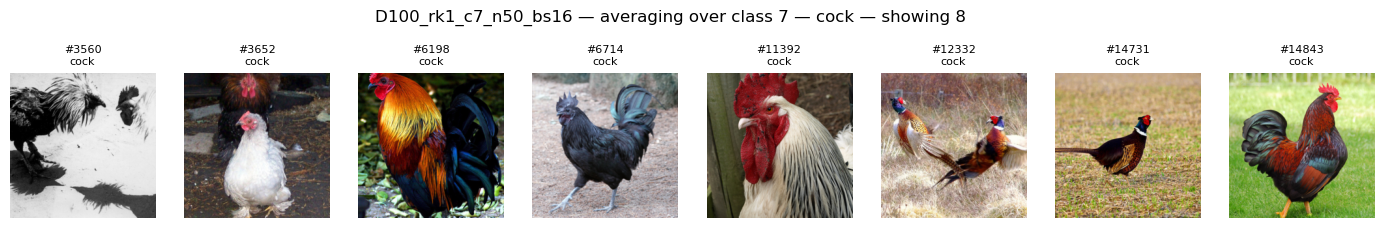

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c7_n1_bs1/inputs.png


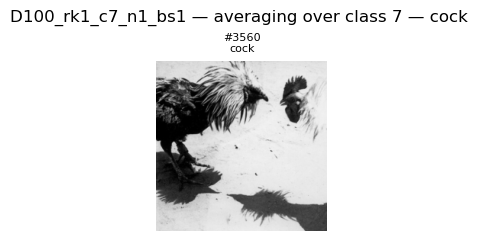

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c207_n50_bs16/inputs.png


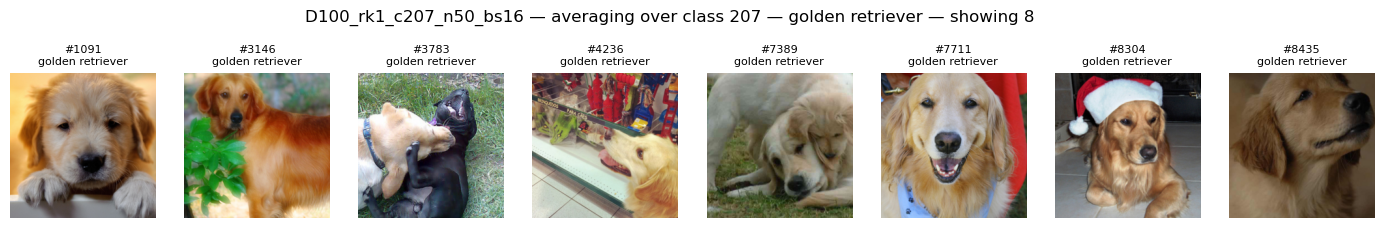

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c207_n1_bs1/inputs.png


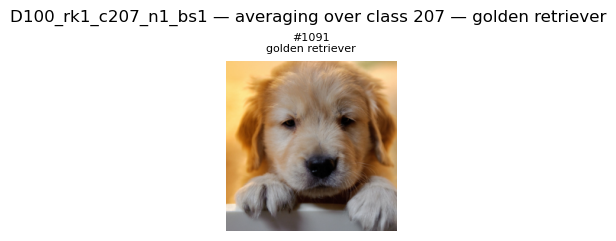

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c282_n50_bs16/inputs.png


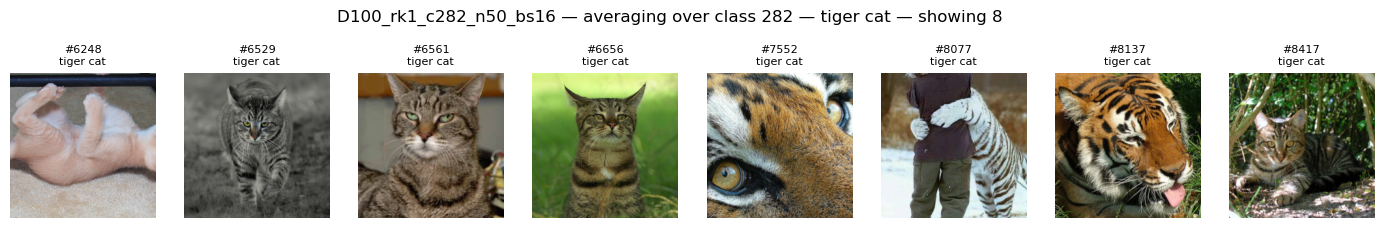

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c282_n1_bs1/inputs.png


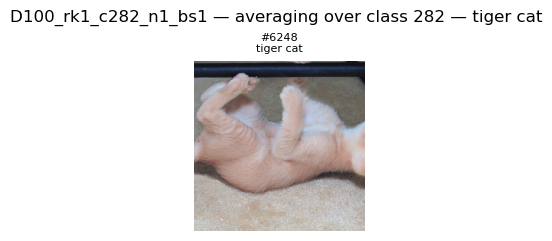

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c289_n50_bs16/inputs.png


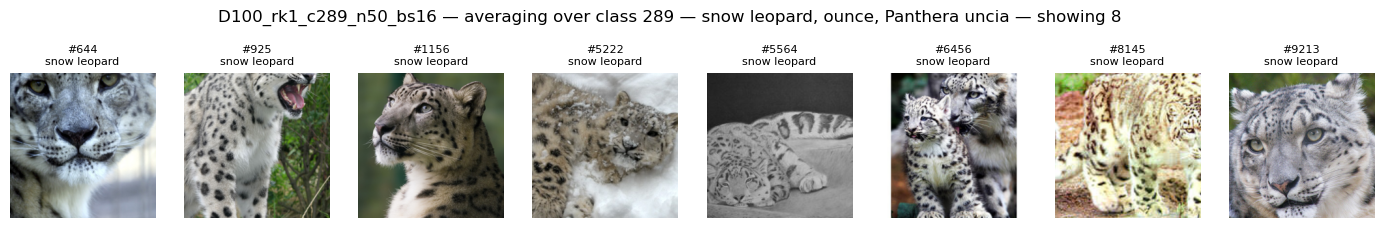

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c289_n1_bs1/inputs.png


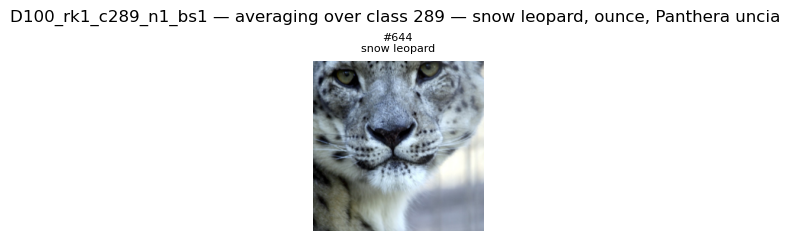

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D50_rk1_c289_n1_bs1/inputs.png


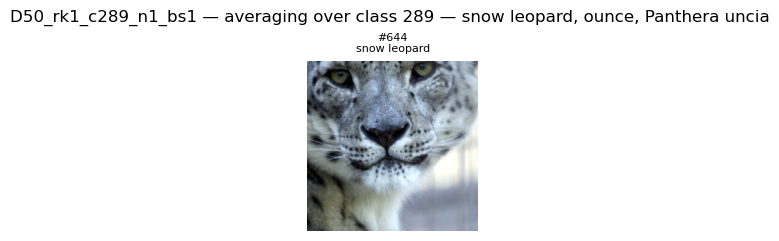

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D25_rk1_c289_n1_bs1/inputs.png


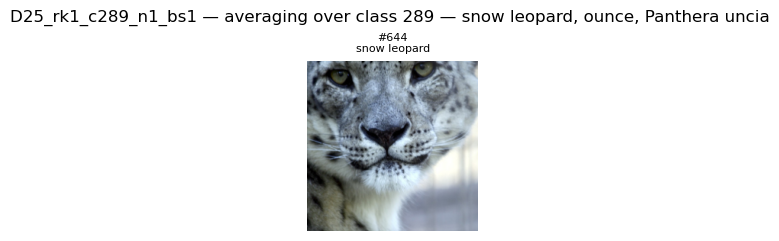

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D9_rk1_c289_n1_bs1/inputs.png


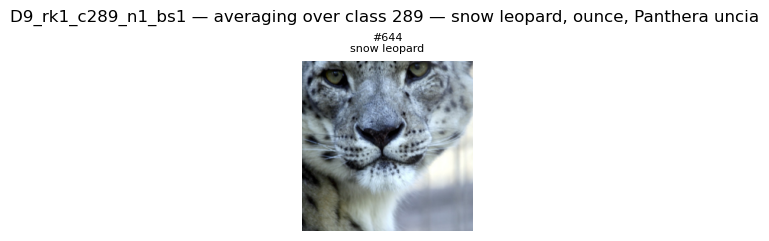

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D8_rk1_c289_n1_bs1/inputs.png


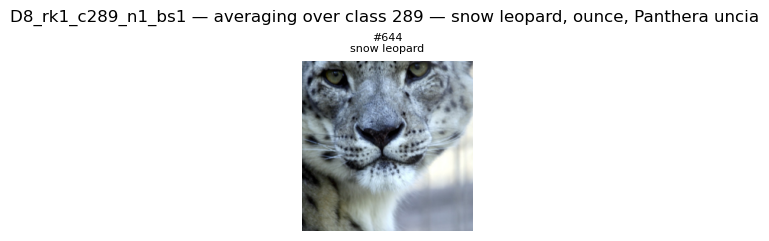

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D5_rk1_c289_n1_bs1/inputs.png


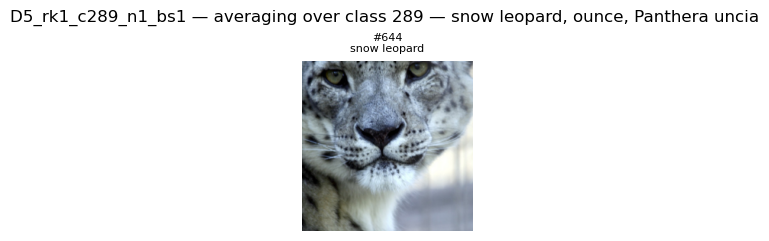

inputs -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D3_rk1_c289_n1_bs1/inputs.png


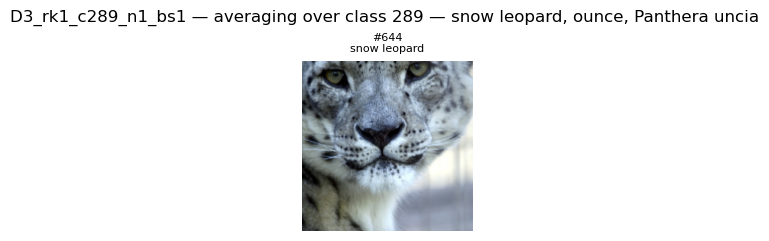

In [4]:
def resolve_run(spec: dict) -> dict:
    """Fill class / indices / batch / folder name from the run, falling back to the defaults."""
    out = dict(spec)
    out["class_id"] = out.get("class_id", CLASS_ID)
    out["max_images"] = out.get("max_images", MAX_IMAGES_PER_CLASS)
    out["batch_size"] = out.get("batch_size", BATCH_SIZE)
    out["fps"] = out.get("fps", FPS)
    if out.get("image_indices") is None:
        if out["class_id"] is not None:
            out["image_indices"] = indices_for_class(out["class_id"], out["max_images"])
        else:
            out["image_indices"] = list(IMAGE_INDICES)
    out["name"] = run_folder_name(out)
    return out


RUNS = [resolve_run(spec) for spec in RUNS]
print("runs:")
for spec in RUNS:
    cid = spec["class_id"]
    who = f"class {cid} — {CLASS_NAMES[cid]}" if cid is not None else "hand-picked images"
    print(f"  {spec['name']}: {who}, {len(spec['image_indices'])} images, batch={spec['batch_size']}, fps={spec['fps']}")

for spec in RUNS:
    indices = spec["image_indices"]
    cid = spec["class_id"]
    subject = f"class {cid} — {CLASS_NAMES[cid]}" if cid is not None else "hand-picked images"
    preview = indices[:8]
    fig, axes = plt.subplots(1, len(preview), figsize=(2.2 * len(preview), 2.8), squeeze=False)
    for ax, idx in zip(axes[0], preview):
        img, label = dataset[idx]
        ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
        ax.set_title(f"#{idx}\n{CLASS_NAMES[label].split(',')[0]}", fontsize=8)
        ax.axis("off")
    fig.suptitle(
        f"{spec['name']} — averaging over {subject}"
        + (f" — showing {len(preview)}" if len(preview) < len(indices) else "")
    )
    run_dir = OUT_DIR / spec["name"]
    run_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(run_dir / "inputs.png", dpi=120, bbox_inches="tight")
    print(f"inputs -> {run_dir / 'inputs.png'}")
    plt.show()


## Trajectory

One pass per chunk of images: run the stem and stages 1-2, then step the shared block `D` times,
folding each state into the running means and the running per-depth statistics.

`h_d` is evaluated once per state and reused both as the statistic and as `k1` of the step, so
Euler costs no extra block evaluation over a plain forward pass.


In [5]:
def rk_step(f, x, h, method, k1=None):
    """One step of dy/dt = f(y). Mirrors `DeltaConvNext._integrate_block`.

    `k1` is accepted because the caller already holds f(x) — that is h_d.
    """
    if k1 is None:
        k1 = f(x)
    if method in (None, "RK1", "EULER"):
        return x + h * k1
    if method == "RK2":
        k2 = f(x + h * k1)
        return x + h / 2 * (k1 + k2)
    if method == "RK3":
        # Kutta's third order rule.
        k2 = f(x + h / 2 * k1)
        k3 = f(x - h * k1 + 2 * h * k2)
        return x + h / 6 * (k1 + 4 * k2 + k3)
    if method == "RK4":
        k2 = f(x + h / 2 * k1)
        k3 = f(x + h / 2 * k2)
        k4 = f(x + h * k3)
        return x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    raise ValueError(f"Unknown integration method: {method!r}")


@torch.no_grad()
def trajectory_stats(indices, *, D, euler_step, method, batch_size=BATCH_SIZE, progress=True):
    """Mean stage-3 trajectory over `indices` plus the two per-depth tables.

    Returns mean_x / mean_h of shape [D+1, C, H, W], plus cosine-distance maps
    `cos_h` / `cos_x` of shape [D, H, W]: at each spatial site the C-vector of that
    location is compared to the same site at the next step, `1 - cos(v_d, v_{d+1})`.
    `norms` has D+1 rows, `pairs` has D. Every scalar is a per-image quantity averaged
    over the images, never a statistic of the mean map.
    """
    method = method.upper() if isinstance(method, str) else method
    n = len(indices)
    w = 1.0 / n
    mean_x = mean_h = cos_map_h = cos_map_x = norm_map_h = l2_map_h = None
    zeros = lambda k: torch.zeros(k, dtype=torch.float64, device=device)
    norm_x, norm_h = zeros(D + 1), zeros(D + 1)
    cos_h, l2_h, cos_x, l2_x = zeros(D), zeros(D), zeros(D), zeros(D)
    cos_h_spatial, cos_x_spatial = zeros(D), zeros(D)

    def f(y):
        return shared_block(y) - y

    starts = range(0, n, batch_size)
    desc = f"D={D} h={euler_step:.4g} m={method or 'RK1'}"
    for start in tqdm(starts, desc=desc, disable=not progress, leave=False):
        batch = load_batch(indices[start : start + batch_size]).to(device)
        x = model.stage2(model.stage1(model.stem(batch)))
        if mean_x is None:
            mean_x = torch.zeros((D + 1, *x.shape[1:]), device=device)
            mean_h = torch.zeros_like(mean_x)
            cos_map_h = torch.zeros((D, *x.shape[2:]), device=device)
            cos_map_x = torch.zeros_like(cos_map_h)
            norm_map_h = torch.zeros((D + 1, *x.shape[2:]), device=device)
            l2_map_h = torch.zeros((D, *x.shape[2:]), device=device)
        h = f(x)
        for d in range(D + 1):
            mean_x[d] += w * x.sum(0)
            mean_h[d] += w * h.sum(0)
            # Per-location vector norm over C: ||h_d[:,i,j]||
            norm_map_h[d] += w * h.norm(dim=1).sum(0)
            norm_x[d] += w * x.flatten(1).norm(dim=1).double().sum()
            norm_h[d] += w * h.flatten(1).norm(dim=1).double().sum()
            if d == D:
                break
            x_next = rk_step(f, x, euler_step, method, k1=h)
            h_next = f(x_next)
            # Flattened C·H·W vector — the table's original cosine distance.
            cos_h[d] += w * (1 - F.cosine_similarity(h.flatten(1), h_next.flatten(1), dim=1)).double().sum()
            l2_h[d] += w * (h - h_next).flatten(1).norm(dim=1).double().sum()
            cos_x[d] += w * (1 - F.cosine_similarity(x.flatten(1), x_next.flatten(1), dim=1)).double().sum()
            l2_x[d] += w * (x - x_next).flatten(1).norm(dim=1).double().sum()
            # Per spatial site: cosine along the C-vector at that (row, col).
            loc_h = 1 - F.cosine_similarity(h, h_next, dim=1)
            loc_x = 1 - F.cosine_similarity(x, x_next, dim=1)
            cos_map_h[d] += w * loc_h.sum(0)
            cos_map_x[d] += w * loc_x.sum(0)
            cos_h_spatial[d] += w * loc_h.mean(dim=(1, 2)).double().sum()
            cos_x_spatial[d] += w * loc_x.mean(dim=(1, 2)).double().sum()
            # Per-location L2 between consecutive residual branches.
            l2_map_h[d] += w * (h - h_next).norm(dim=1).sum(0)
            x, h = x_next, h_next

    depths = torch.arange(D + 1)
    norms = pd.DataFrame(
        {
            "d": depths.numpy(),
            "t": (depths * euler_step).numpy(),
            "norm_h": norm_h.cpu().numpy(),
            "norm_x": norm_x.cpu().numpy(),
        }
    )
    norms["norm_h_over_norm_x"] = norms["norm_h"] / norms["norm_x"]
    pairs = pd.DataFrame(
        {
            "d": torch.arange(D).numpy(),
            "pair": [f"{d}->{d + 1}" for d in range(D)],
            "cos_dist_h": cos_h.cpu().numpy(),
            "cos_dist_h_spatial": cos_h_spatial.cpu().numpy(),
            "l2_h": l2_h.cpu().numpy(),
            "cos_dist_x": cos_x.cpu().numpy(),
            "cos_dist_x_spatial": cos_x_spatial.cpu().numpy(),
            "l2_x": l2_x.cpu().numpy(),
        }
    )
    return {
        "D": D,
        "euler_step": euler_step,
        "method": method,
        "n_images": n,
        "mean_x": mean_x.cpu(),
        "mean_h": mean_h.cpu(),
        "cos_h": cos_map_h.cpu(),
        "cos_x": cos_map_x.cpu(),
        "norm_h": norm_map_h.cpu(),
        "l2_h": l2_map_h.cpu(),
        "norms": norms,
        "pairs": pairs,
    }


In [6]:
results: dict[str, dict] = {}
for spec in RUNS:
    D = spec["D"]
    step = spec.get("euler_step")
    if step is None:
        step = model.stage3_length / D
    method = spec.get("method")
    name = spec["name"]
    print(f"{name}: D={D} euler_step={step:.4g} method={method or 'RK1'} batch={spec['batch_size']}")
    res = trajectory_stats(
        spec["image_indices"],
        D=D,
        euler_step=step,
        method=method,
        batch_size=spec["batch_size"],
    )
    res["name"] = name
    res["spec"] = spec
    results[name] = res
    print(f"  mean maps {tuple(res['mean_x'].shape)}  norms {res['norms'].shape}  pairs {res['pairs'].shape}")


D100_rk1_c7_n50_bs16: D=100 euler_step=0.09 method=RK1 batch=4


D=100 h=0.09 m=RK1:   0%|          | 0/13 [00:00<?, ?it/s]

  mean maps (101, 384, 14, 14)  norms (101, 5)  pairs (100, 8)
D100_rk1_c7_n1_bs1: D=100 euler_step=0.09 method=RK1 batch=1


D=100 h=0.09 m=RK1:   0%|          | 0/1 [00:00<?, ?it/s]

  mean maps (101, 384, 14, 14)  norms (101, 5)  pairs (100, 8)
D100_rk1_c207_n50_bs16: D=100 euler_step=0.09 method=RK1 batch=4


...

  mean maps (9, 384, 14, 14)  norms (9, 5)  pairs (8, 8)
D5_rk1_c289_n1_bs1: D=5 euler_step=1.8 method=RK1 batch=1


D=5 h=1.8 m=RK1:   0%|          | 0/1 [00:00<?, ?it/s]

  mean maps (6, 384, 14, 14)  norms (6, 5)  pairs (5, 8)
D3_rk1_c289_n1_bs1: D=3 euler_step=3 method=RK1 batch=1


D=3 h=3 m=RK1:   0%|          | 0/1 [00:00<?, ?it/s]

  mean maps (4, 384, 14, 14)  norms (4, 5)  pairs (3, 8)


## Tables

`norms` has `D+1` rows (one per state), `pairs` has `D`. Both are written to
`outputs/featureMaps/<run>/`.


In [7]:
for name, res in results.items():
    spec = res["spec"]
    run_dir = OUT_DIR / name
    run_dir.mkdir(parents=True, exist_ok=True)
    res["norms"].to_csv(run_dir / "table_norms.csv", index=False)
    res["pairs"].to_csv(run_dir / "table_pairs.csv", index=False)
    config = {
        "name": name,
        "D": res["D"],
        "euler_step": res["euler_step"],
        "method": res["method"] or "RK1",
        "split": SPLIT,
        "class_id": spec["class_id"],
        "class_name": CLASS_NAMES[spec["class_id"]] if spec["class_id"] is not None else None,
        "max_images": spec["max_images"],
        "n_images": len(spec["image_indices"]),
        "image_indices": list(spec["image_indices"]),
        "batch_size": spec["batch_size"],
        "fps": spec["fps"],
        "video_maps": list(VIDEO_MAPS),
        "channels": CHANNELS,
        "n_auto_channels": N_AUTO_CHANNELS,
    }
    (run_dir / "config.json").write_text(json.dumps(config, indent=2) + "\n")
    if SAVE_TENSORS:
        torch.save(
            {
                "mean_x": res["mean_x"],
                "mean_h": res["mean_h"],
                "cos_h": res["cos_h"],
                "cos_x": res["cos_x"],
                "norm_h": res["norm_h"],
                "l2_h": res["l2_h"],
            },
            run_dir / "mean_maps.pt",
        )
    print(f"=== {name}  (D={res['D']}, step={res['euler_step']:.4g}, {res['method'] or 'RK1'}) ===")
    print(f"wrote {run_dir / 'config.json'}")
    print(f"norms — {len(res['norms'])} rows")
    display(res["norms"].round(4))
    print(f"pairs — {len(res['pairs'])} rows")
    display(res["pairs"].round(4))


=== D100_rk1_c7_n50_bs16  (D=100, step=0.09, RK1) ===
wrote /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c7_n50_bs16/config.json
norms — 101 rows


,d,t,norm_h,norm_x,norm_h_over_norm_x
0,0,0.00,268.5385,164.8203,1.6293
1,1,0.09,272.5955,180.9677,1.5063
2,2,0.18,277.1343,199.0585,1.3922
3,3,0.27,282.1145,218.7673,1.2896
4,4,0.36,287.4943,239.8553,1.1986
...,...,...,...,...,...
96,96,8.64,186.7815,3528.7829,0.0529
97,97,8.73,183.3223,3542.7586,0.0517
98,98,8.82,180.0336,3556.4033,0.0506
99,99,8.91,176.9081,3569.7341,0.0496


pairs — 100 rows


,d,pair,cos_dist_h,cos_dist_h_spatial,l2_h,cos_dist_x,cos_dist_x_spatial,l2_x
0,0,0->1,0.0001,0.0001,5.9675,0.0054,0.0051,24.1685
1,1,1->2,0.0001,0.0001,6.3061,0.0038,0.0035,24.5336
2,2,2->3,0.0001,0.0001,6.6439,0.0027,0.0024,24.9421
3,3,3->4,0.0001,0.0001,6.9652,0.0019,0.0017,25.3903
4,4,4->5,0.0001,0.0001,7.2599,0.0014,0.0012,25.8745
...,...,...,...,...,...,...,...,...
95,95,95->96,0.0001,0.0002,4.6270,0.0000,0.0000,17.1378
96,96,96->97,0.0001,0.0002,4.4238,0.0000,0.0000,16.8103
97,97,97->98,0.0001,0.0001,4.2272,0.0000,0.0000,16.4990
98,98,98->99,0.0001,0.0001,4.0410,0.0000,0.0000,16.2030


=== D100_rk1_c7_n1_bs1  (D=100, step=0.09, RK1) ===
wrote /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c7_n1_bs1/config.json
norms — 101 rows


...

,d,pair,cos_dist_h,cos_dist_h_spatial,l2_h,cos_dist_x,cos_dist_x_spatial,l2_x
0,0,0->1,0.0656,0.0470,222.9250,0.2444,0.2291,466.5236
1,1,1->2,0.1506,0.0783,270.1270,0.0266,0.0196,801.1102
2,2,2->3,0.2352,0.1025,642.9904,0.0198,0.0077,920.5517
3,3,3->4,0.6938,0.6887,902.0878,0.0273,0.0050,1697.8391
4,4,4->5,0.8088,0.8628,391.1228,0.0121,0.0022,675.3347


=== D3_rk1_c289_n1_bs1  (D=3, step=3, RK1) ===
wrote /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D3_rk1_c289_n1_bs1/config.json
norms — 4 rows


,d,t,norm_h,norm_x,norm_h_over_norm_x
0,0,0.0,259.1798,161.6667,1.6032
1,1,3.0,651.0995,882.2234,0.7380
2,2,6.0,605.4192,2750.5713,0.2201
3,3,9.0,722.5018,4292.7749,0.1683


pairs — 3 rows


,d,pair,cos_dist_h,cos_dist_h_spatial,l2_h,cos_dist_x,cos_dist_x_spatial,l2_x
0,0,0->1,0.1397,0.1053,448.0467,0.2993,0.2823,777.5394
1,1,1->2,0.3148,0.1964,500.2966,0.0669,0.0417,1953.2985
2,2,2->3,0.2393,0.1326,472.2485,0.0390,0.0131,1816.2576


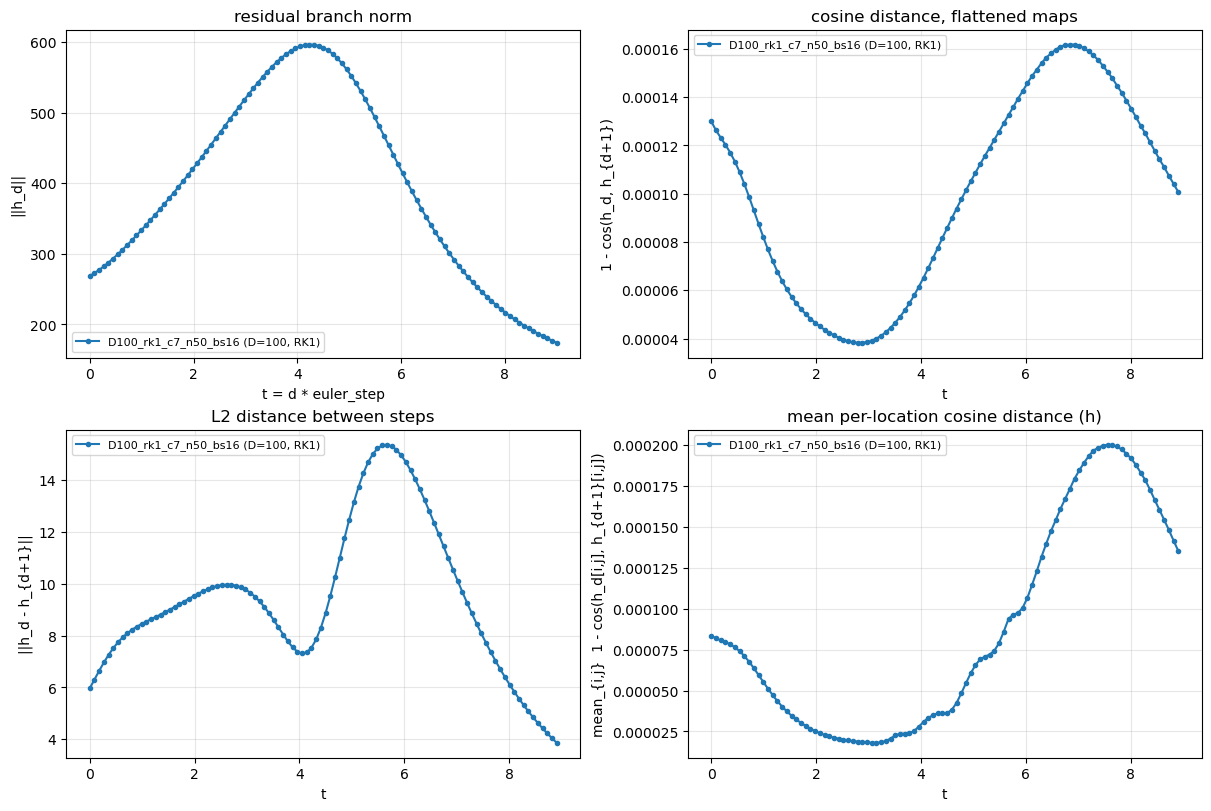

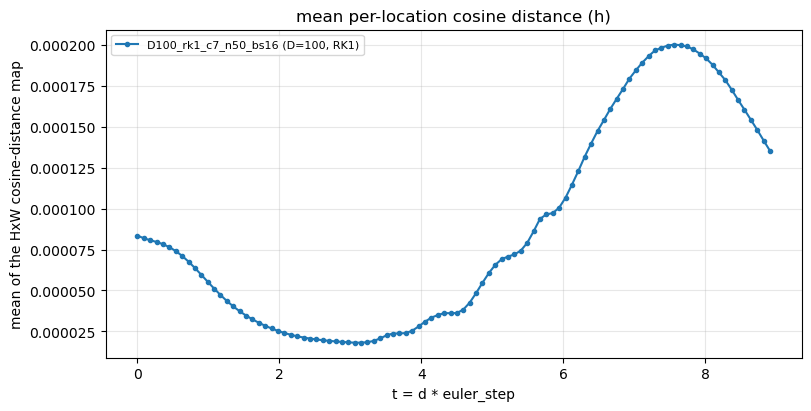

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c7_n50_bs16/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c7_n50_bs16/cos_spatial.png


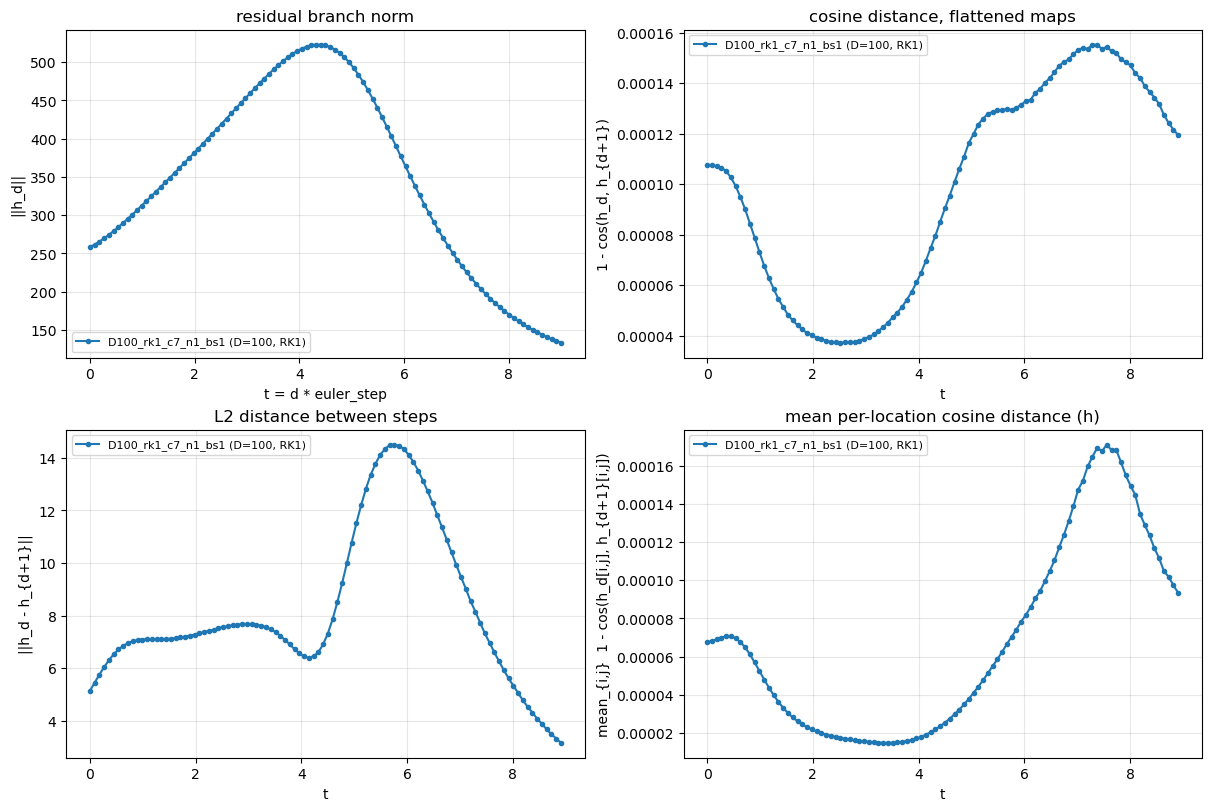

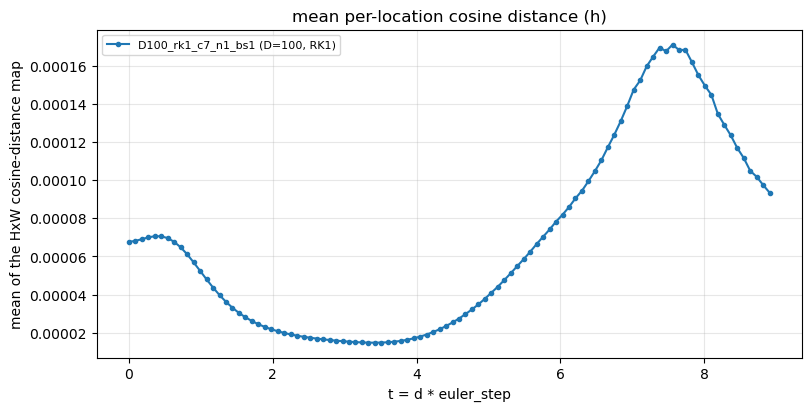

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c7_n1_bs1/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c7_n1_bs1/cos_spatial.png


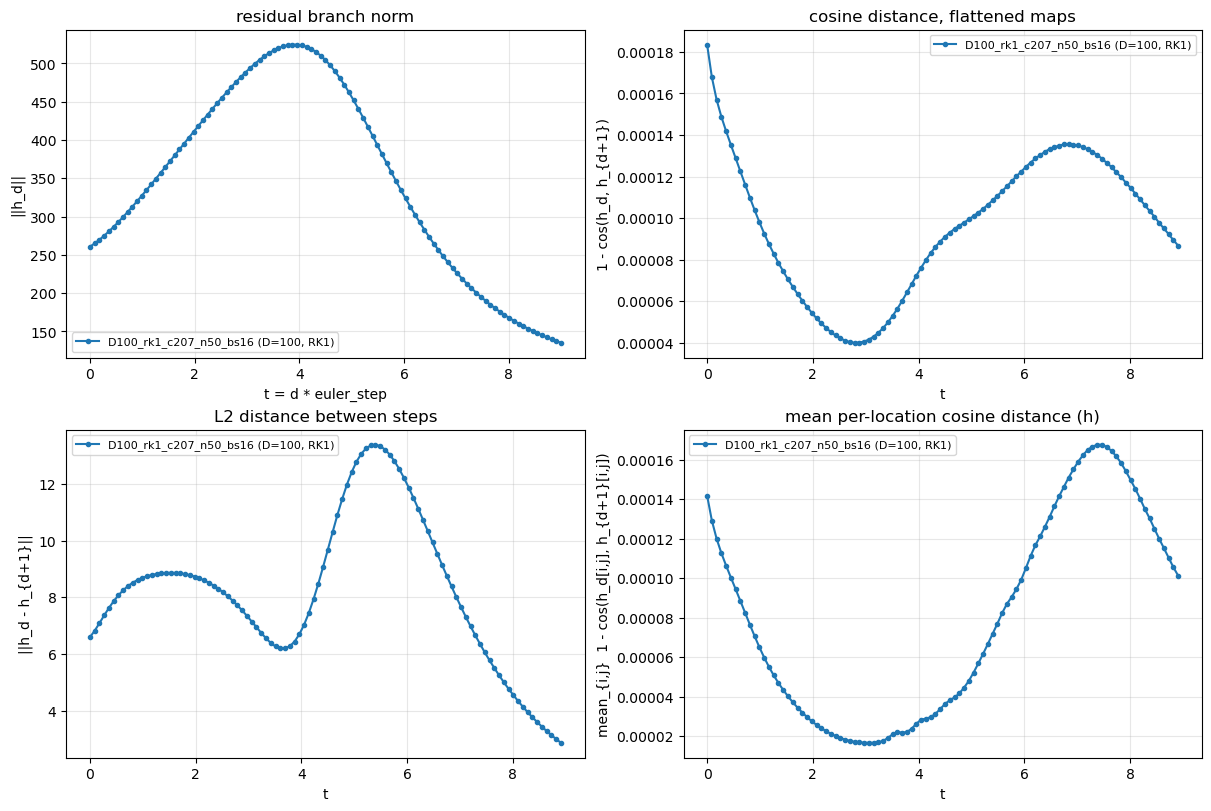

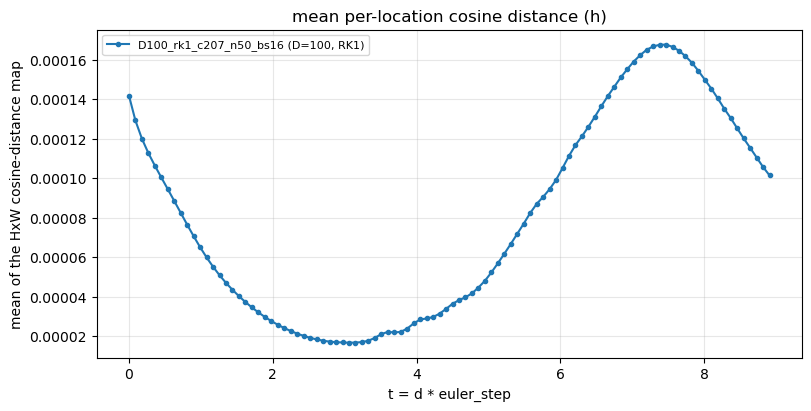

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c207_n50_bs16/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c207_n50_bs16/cos_spatial.png


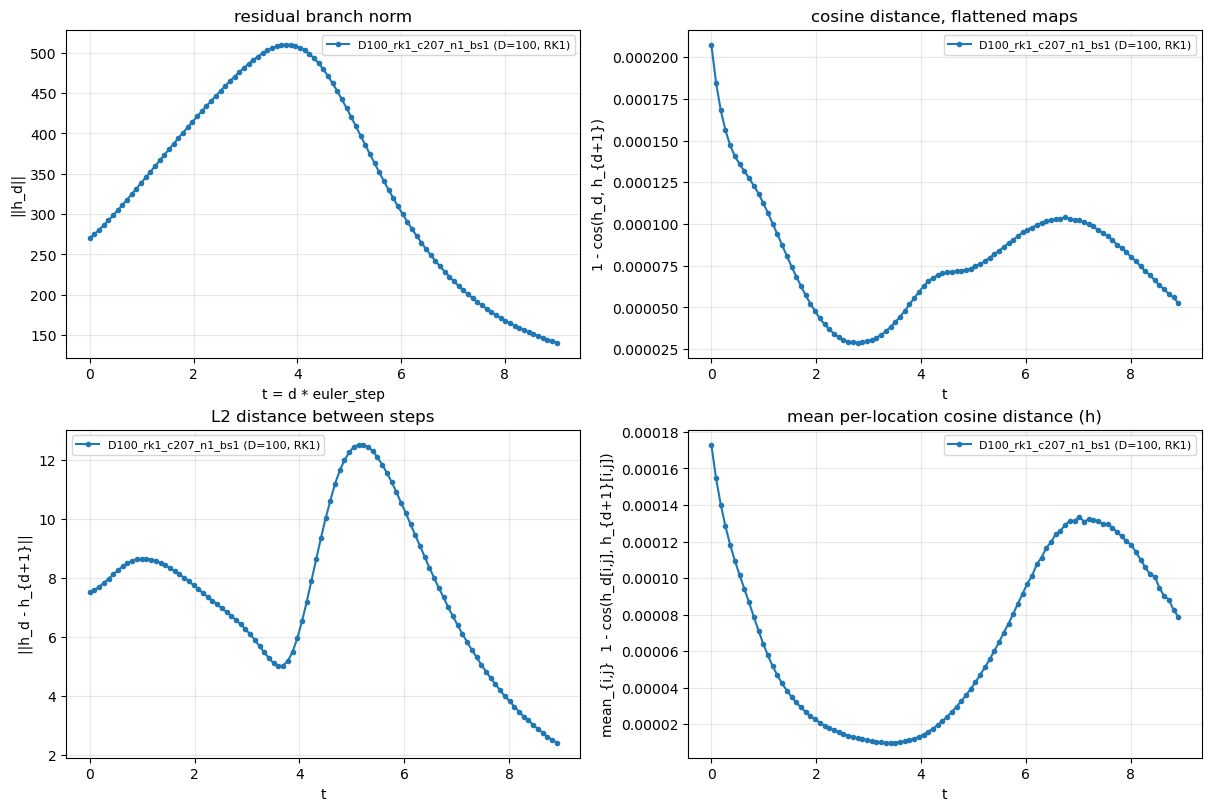

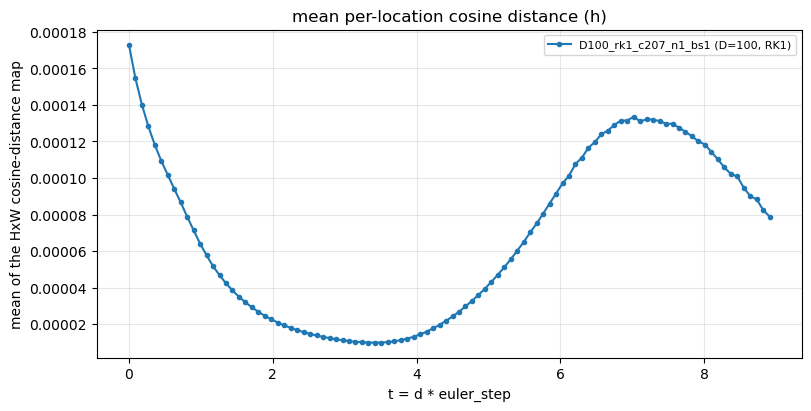

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c207_n1_bs1/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c207_n1_bs1/cos_spatial.png


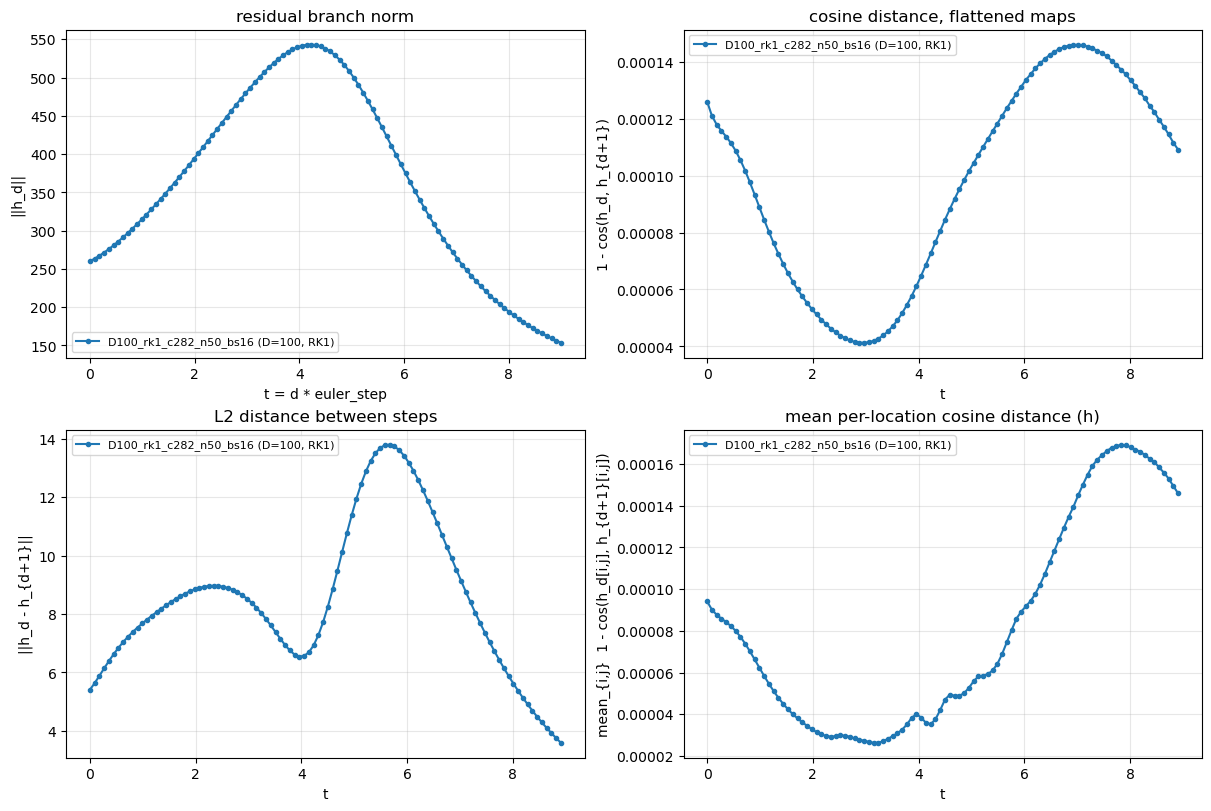

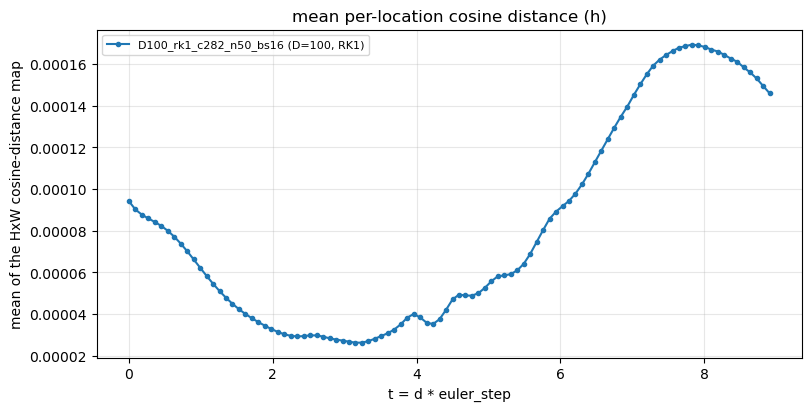

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c282_n50_bs16/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c282_n50_bs16/cos_spatial.png


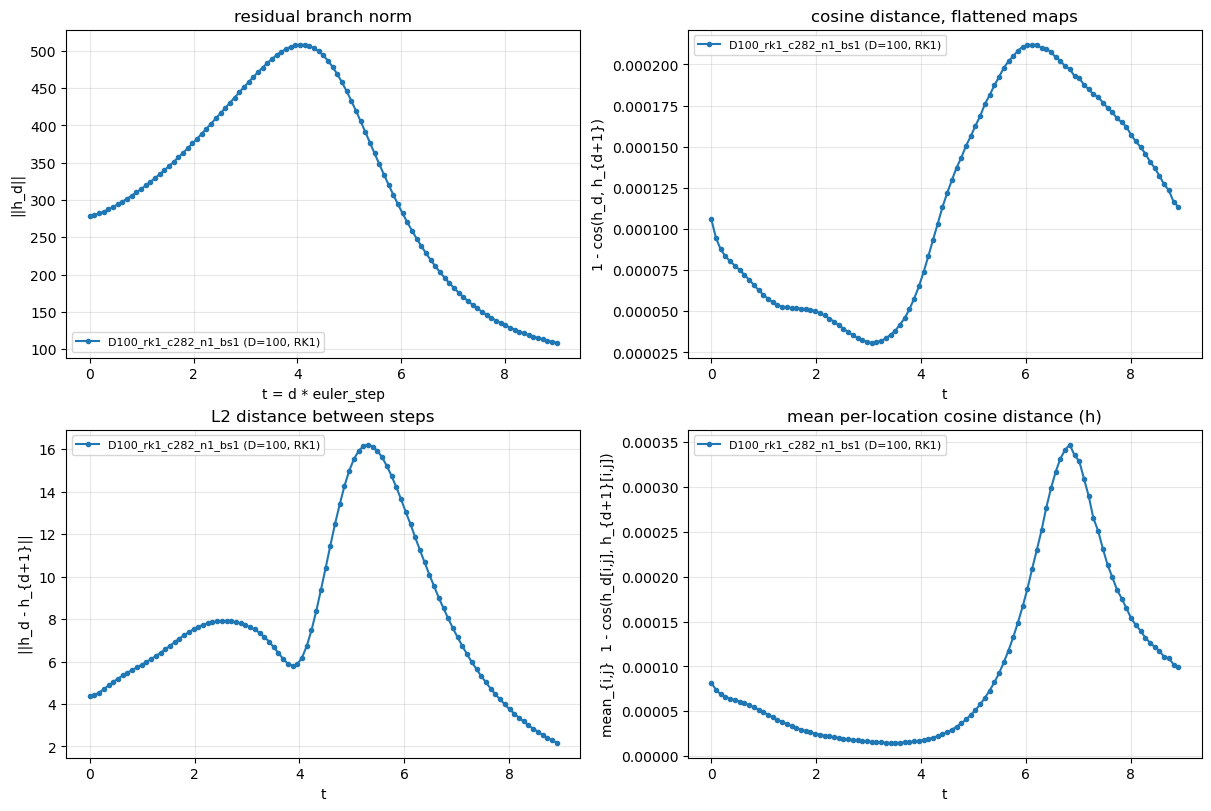

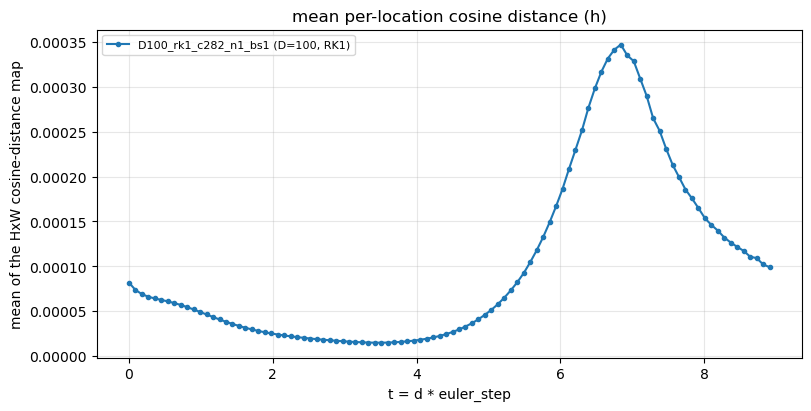

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c282_n1_bs1/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c282_n1_bs1/cos_spatial.png


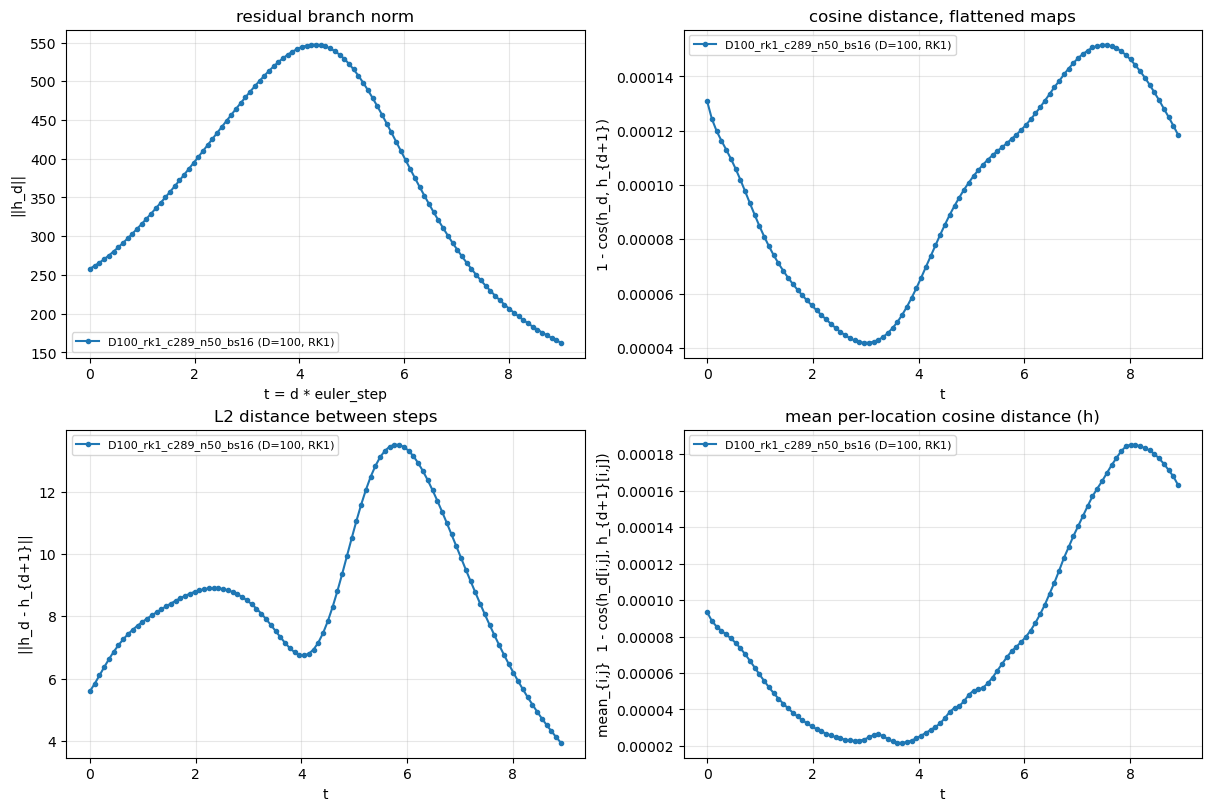

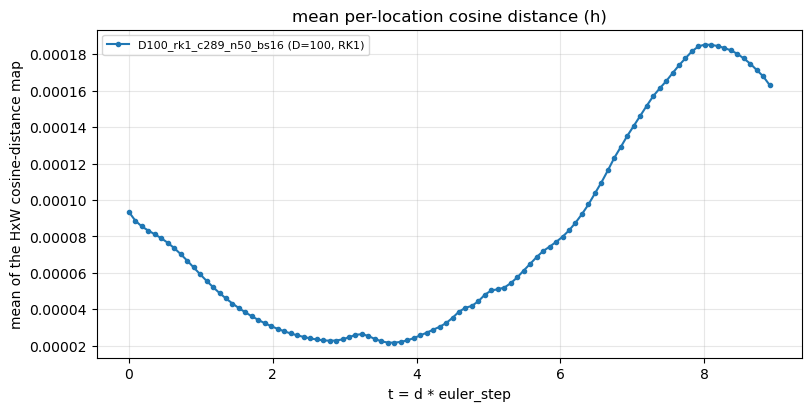

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c289_n50_bs16/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c289_n50_bs16/cos_spatial.png


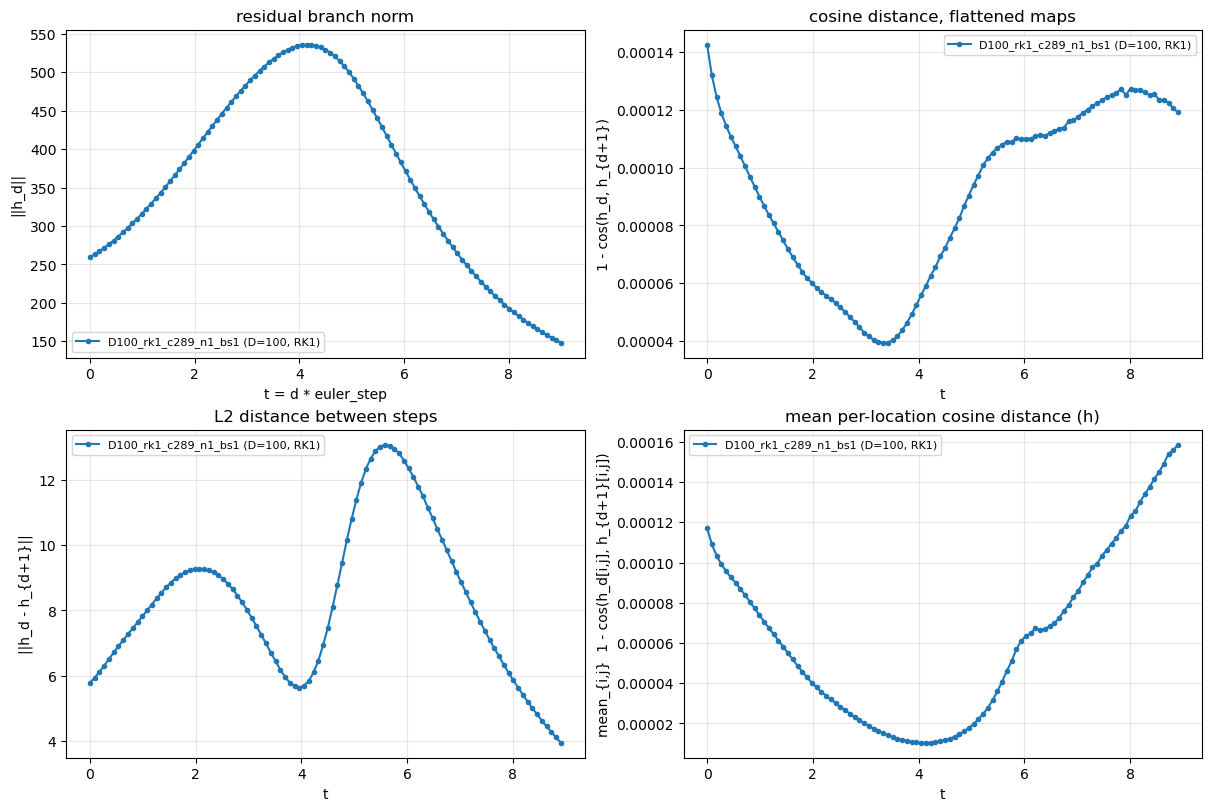

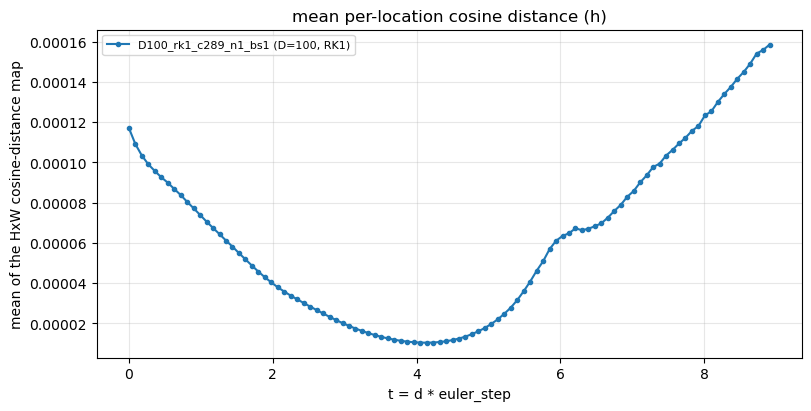

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c289_n1_bs1/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D100_rk1_c289_n1_bs1/cos_spatial.png


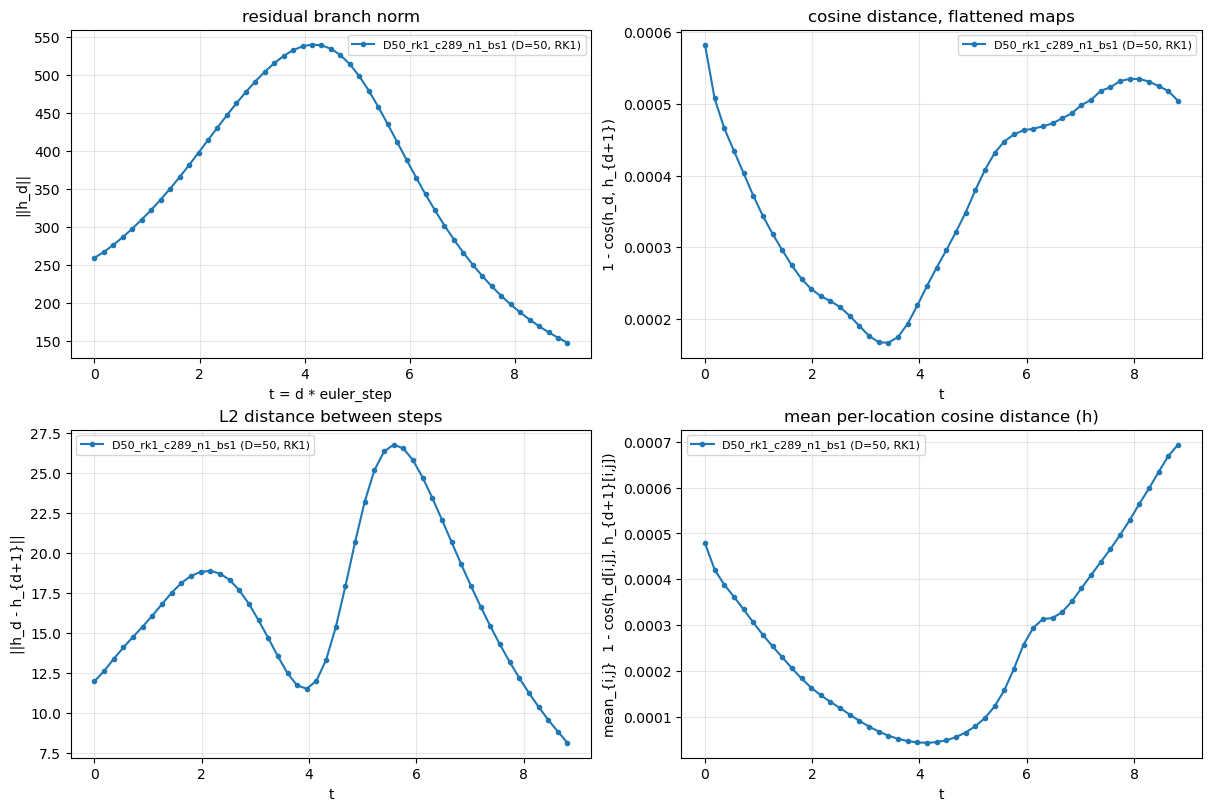

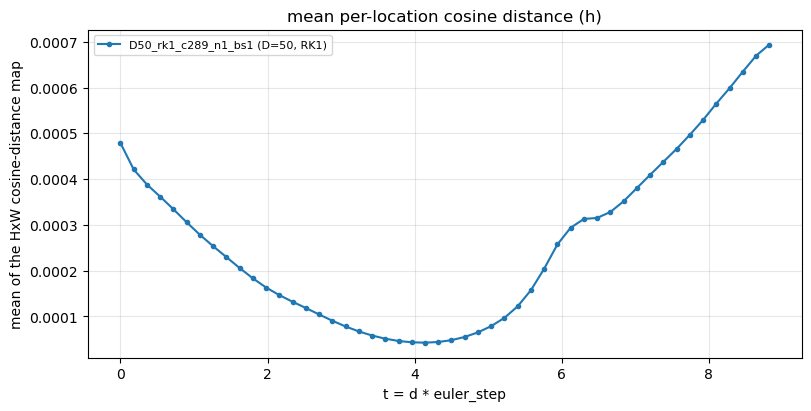

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D50_rk1_c289_n1_bs1/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D50_rk1_c289_n1_bs1/cos_spatial.png


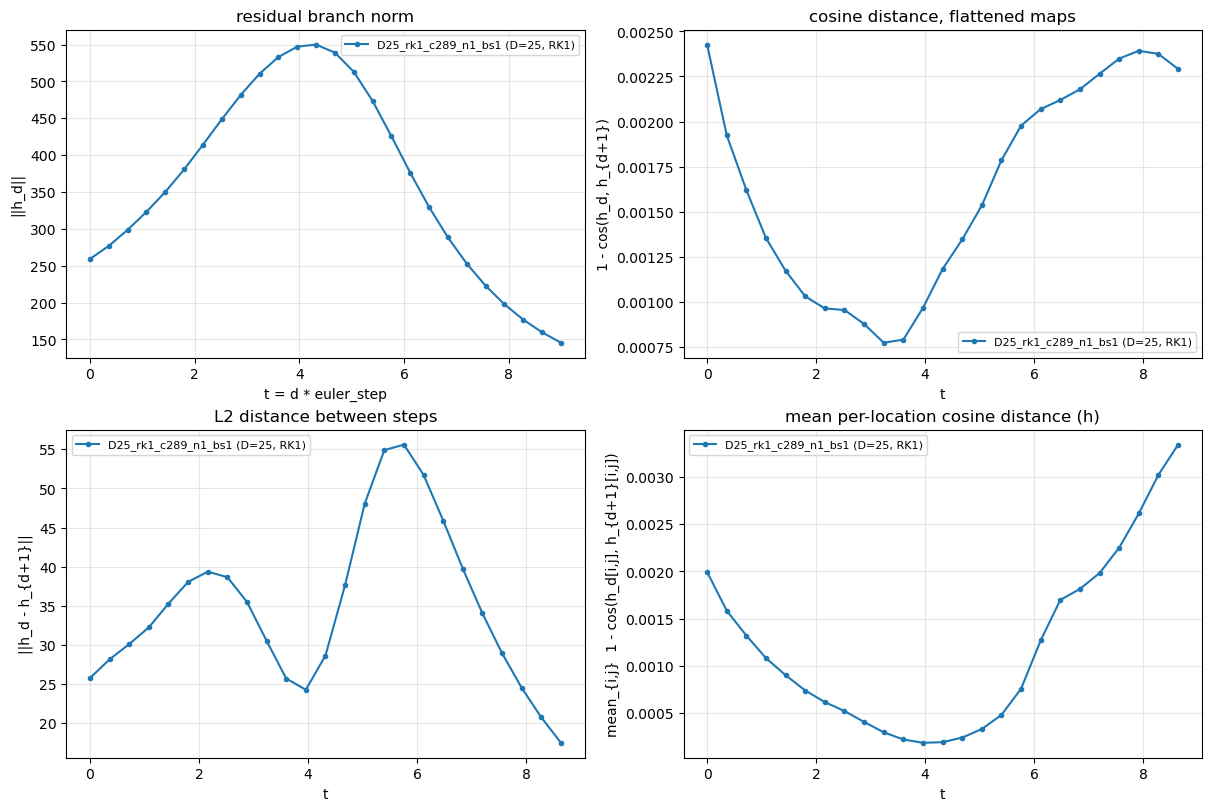

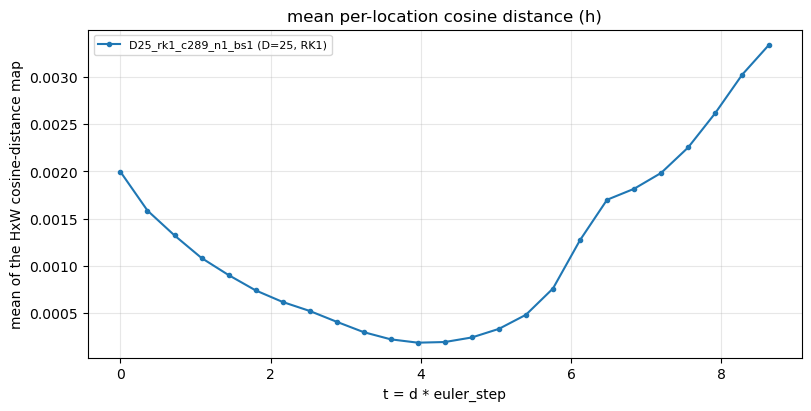

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D25_rk1_c289_n1_bs1/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D25_rk1_c289_n1_bs1/cos_spatial.png


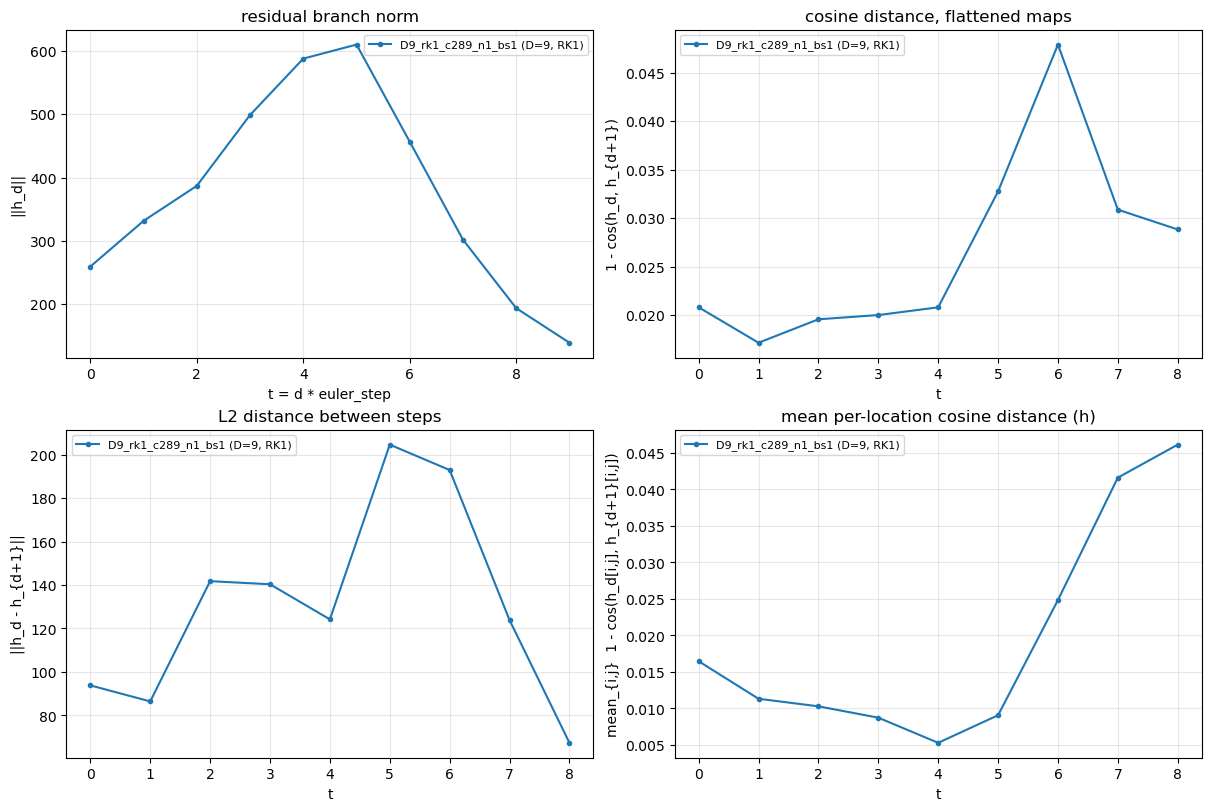

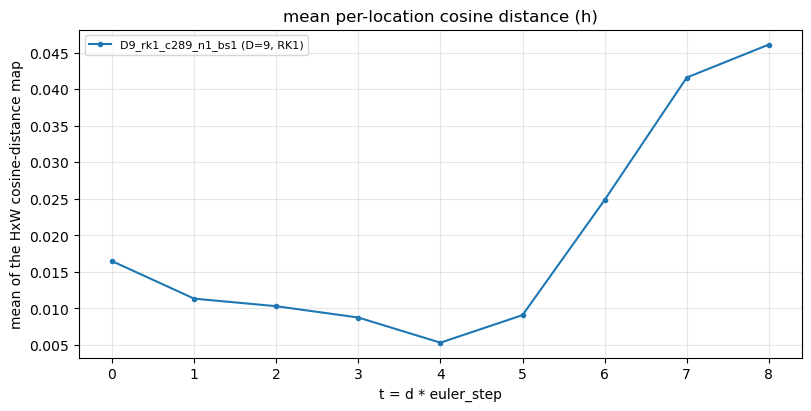

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D9_rk1_c289_n1_bs1/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D9_rk1_c289_n1_bs1/cos_spatial.png


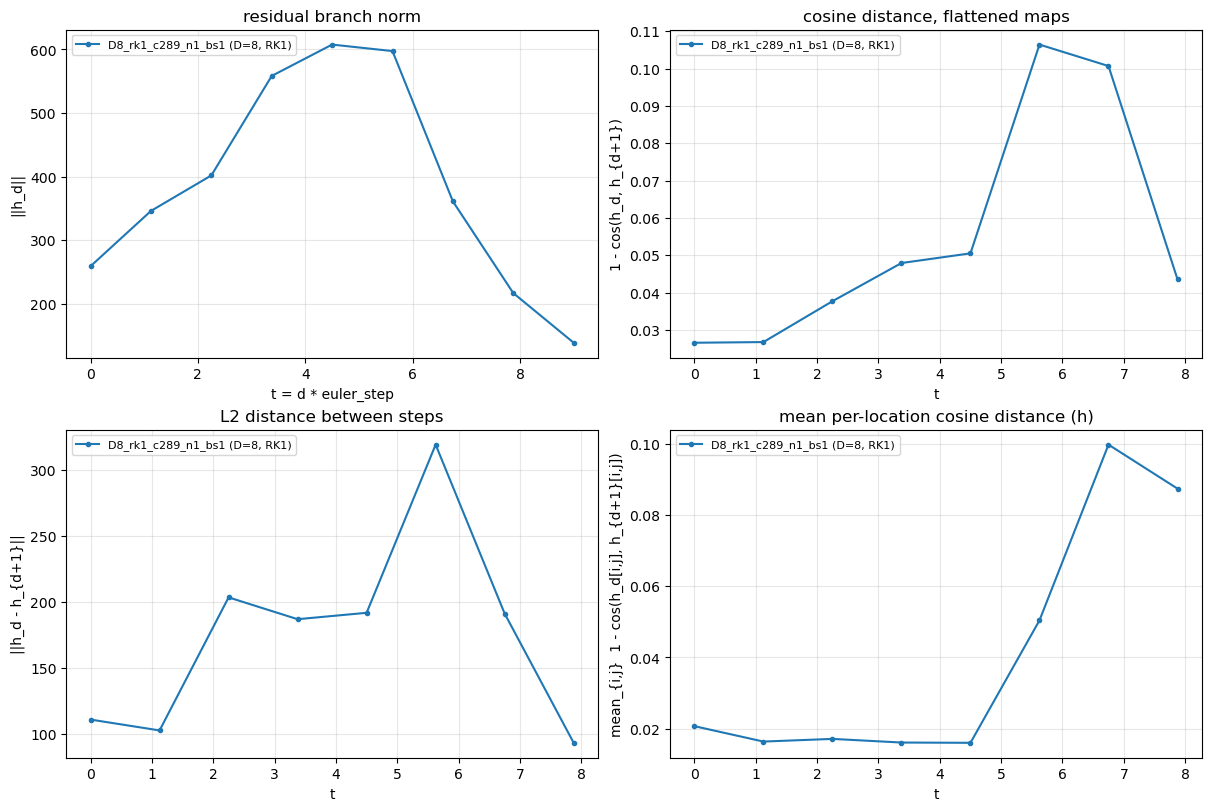

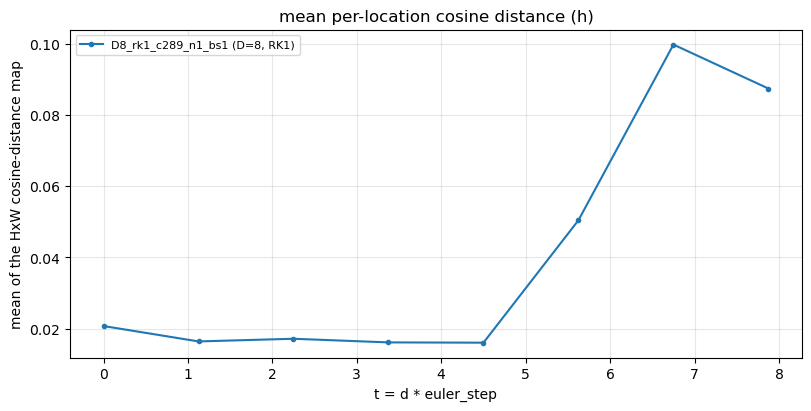

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D8_rk1_c289_n1_bs1/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D8_rk1_c289_n1_bs1/cos_spatial.png


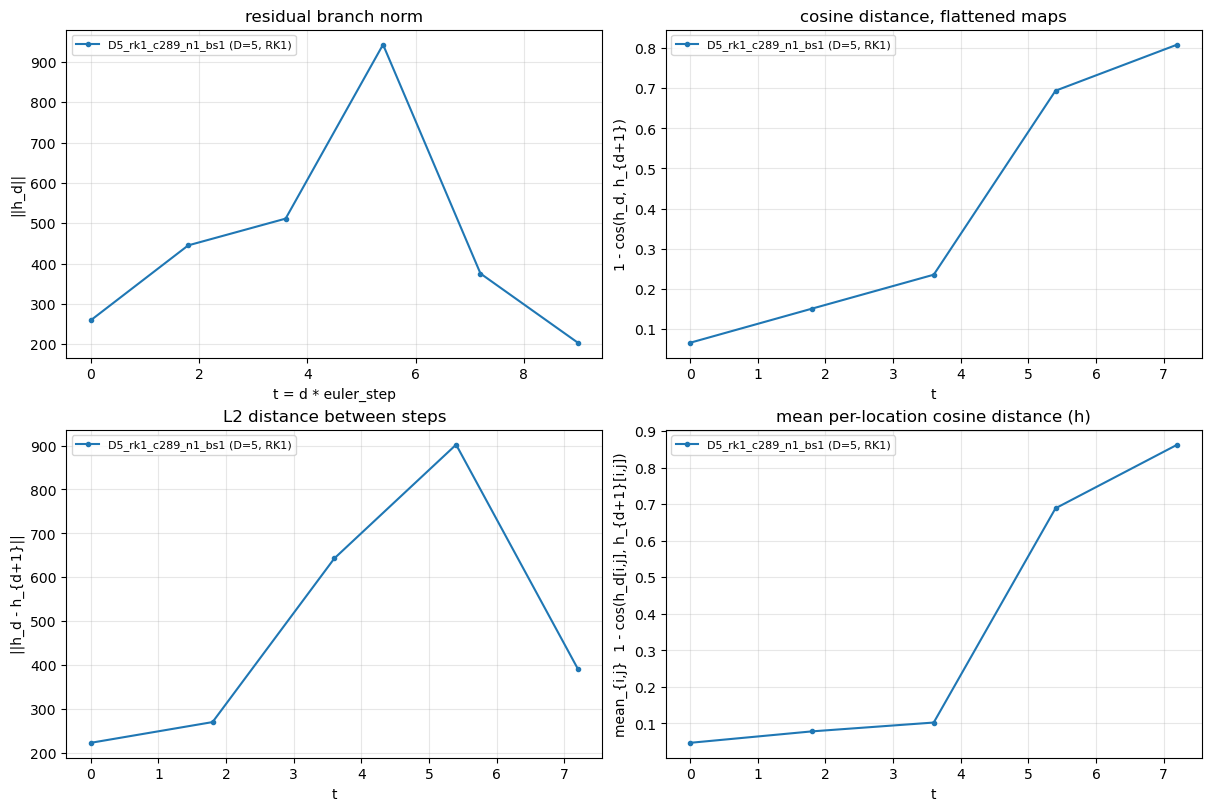

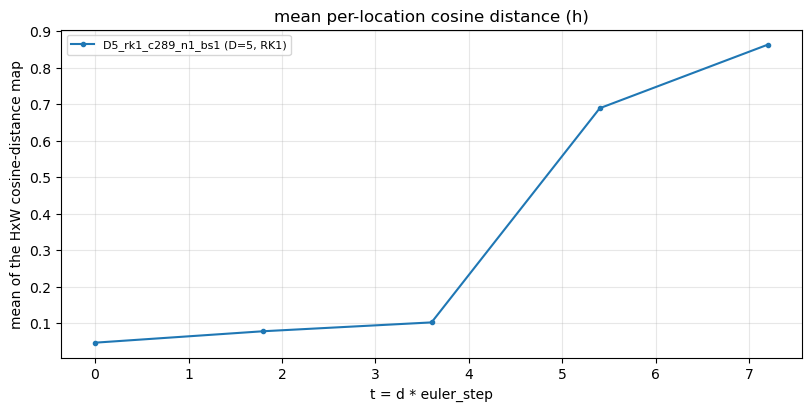

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D5_rk1_c289_n1_bs1/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D5_rk1_c289_n1_bs1/cos_spatial.png


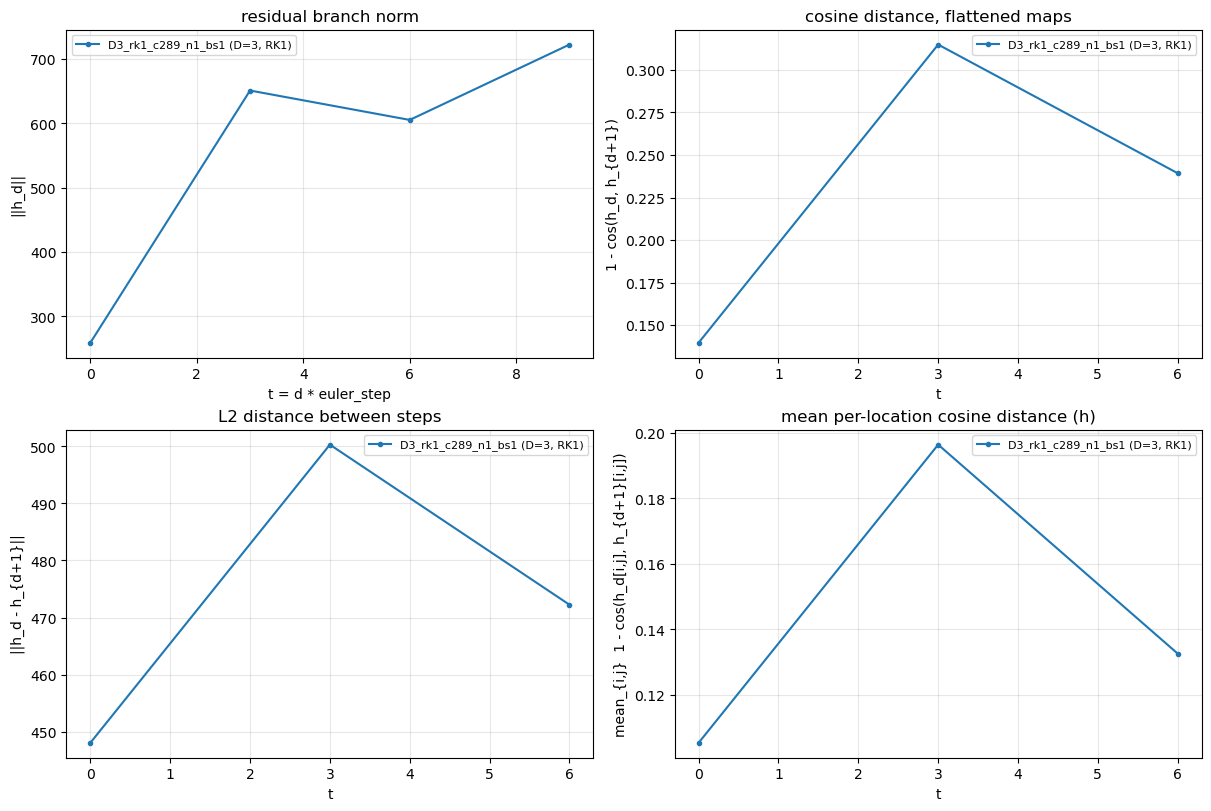

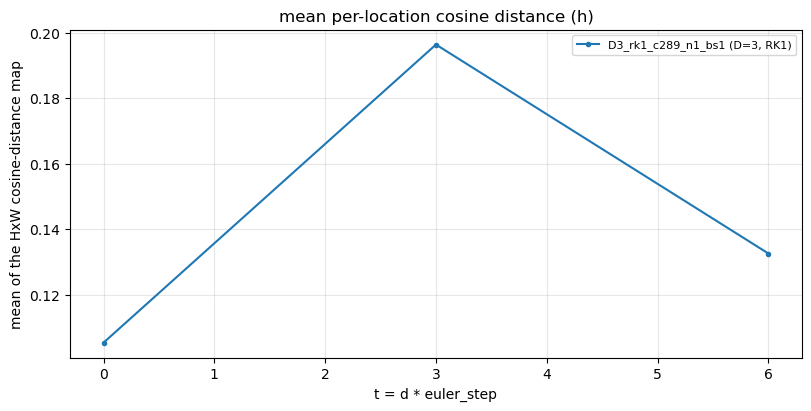

figures -> /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D3_rk1_c289_n1_bs1/metrics.png , /home/jaume/Projects/ML_and_DL/DeltaNeuralODE/outputs/featureMaps/D3_rk1_c289_n1_bs1/cos_spatial.png


In [8]:
for name, res in results.items():
    run_dir = OUT_DIR / name
    run_dir.mkdir(parents=True, exist_ok=True)
    norms, pairs = res["norms"], res["pairs"]
    t_pair = pairs["d"] * res["euler_step"]
    label = f"{name} (D={res['D']}, {res['method'] or 'RK1'})"

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
    axes[0, 0].plot(norms["t"], norms["norm_h"], marker="o", ms=3, label=label)
    axes[0, 1].plot(t_pair, pairs["cos_dist_h"], marker="o", ms=3, label=label)
    axes[1, 0].plot(t_pair, pairs["l2_h"], marker="o", ms=3, label=label)
    axes[1, 1].plot(t_pair, pairs["cos_dist_h_spatial"], marker="o", ms=3, label=label)
    axes[0, 0].set(xlabel="t = d * euler_step", ylabel="||h_d||", title="residual branch norm")
    axes[0, 1].set(xlabel="t", ylabel="1 - cos(h_d, h_{d+1})", title="cosine distance, flattened maps")
    axes[1, 0].set(xlabel="t", ylabel="||h_d - h_{d+1}||", title="L2 distance between steps")
    axes[1, 1].set(
        xlabel="t",
        ylabel="mean_{i,j}  1 - cos(h_d[i,j], h_{d+1}[i,j])",
        title="mean per-location cosine distance (h)",
    )
    for ax in axes.flat:
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    fig.savefig(run_dir / "metrics.png", dpi=140)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
    ax.plot(t_pair, pairs["cos_dist_h_spatial"], marker="o", ms=3, label=label)
    ax.set(
        xlabel="t = d * euler_step",
        ylabel="mean of the HxW cosine-distance map",
        title="mean per-location cosine distance (h)",
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.savefig(run_dir / "cos_spatial.png", dpi=140)
    plt.show()
    print(f"figures -> {run_dir / 'metrics.png'} , {run_dir / 'cos_spatial.png'}")


## Feature-map videos

`VIDEO_MAPS` options:

- `h` / `x` — one video per channel (`H×W`): `h_ch236.gif`
- `cos_h` / `cos_x` — `H×W` cosine distance between consecutive C-vectors (`D` frames)
- `norm_h` — `H×W` map of `||h_d[:,i,j]||` (vector norm over channels, `D+1` frames)
- `l2_h` — `H×W` map of `||h_d[:,i,j] - h_{d+1}[:,i,j]||` (`D` frames)
- `h_CH` / `x_CH` — `C×H` slice at `W//2` (channels horizontal, H vertical)

## Scatters

Two scatters, one point per feature (each scalar in the `C×H×W` mean map), coloured by depth `d`:

- **X (cumulative)** — `(x_d, x_{d+1})`: how the state maps under one step
- **H (increment)** — `(h_d, h_{d+1})`: how the residual branch maps under one step


In [9]:
def most_active_channels(mean_map: torch.Tensor, k: int) -> list[int]:
    """Channels whose mean map moves the most over the trajectory (summed step L2)."""
    total_variation = (mean_map[1:] - mean_map[:-1]).flatten(2).norm(dim=2).sum(0)
    return total_variation.argsort(descending=True)[:k].tolist()


CHANNEL_KINDS = [k for k in VIDEO_MAPS if k in ("h", "x")]
MAP_KINDS = [k for k in VIDEO_MAPS if k in ("cos_h", "cos_x", "norm_h", "l2_h", "h_CH", "x_CH")]

first = next(iter(results.values()))
# Rank on the first channel map (h/x); fall back to mean_h if only map kinds are requested.
rank_kind = CHANNEL_KINDS[0] if CHANNEL_KINDS else "h"
reference = first[f"mean_{rank_kind}"]
channels = CHANNELS if CHANNELS is not None else most_active_channels(reference, N_AUTO_CHANNELS)
print(f"channels: {channels} (of {reference.shape[1]}, ranked on {rank_kind}_d)")
print(f"VIDEO_MAPS={VIDEO_MAPS}")


channels: [236, 56, 202] (of 384, ranked on h_d)
VIDEO_MAPS=['h', 'x', 'cos_h', 'norm_h', 'l2_h', 'h_CH', 'x_CH']


In [10]:
FIGSIZE, DPI = (4.4, 4.2), 130
# C×H: channels on x (vertical stripes), H on y. Scale pixels so both axes are readable.
CH_PX_PER_CHANNEL = 3
CH_PX_PER_H = 16
CH_DPI = 120


def is_pair_kind(kind: str) -> bool:
    """Kinds with D frames indexed by the step d → d+1."""
    return kind in ("cos_h", "cos_x", "l2_h")


def ch_cut(maps: torch.Tensor) -> torch.Tensor:
    """Slice at W//2 → [T, H, C]: x=channel (vertical lines), y=spatial H."""
    w = maps.shape[-1] // 2
    return maps[..., w].permute(0, 2, 1)


def ch_figsize(n_h: int, n_c: int) -> tuple[float, float]:
    """Wide canvas sized from data (≈384×14), with extra vertical stretch for H rows."""
    width = (n_c * CH_PX_PER_CHANNEL) / CH_DPI + 0.8
    height = (n_h * CH_PX_PER_H) / CH_DPI + 1.8  # title + horizontal colorbar
    return width, height


def render_frames(maps: torch.Tensor, out_dir: Path, *, title: str, kind: str) -> list[Path]:
    """One PNG per depth. Fixed figsize and no bbox_inches, so every frame is the same size."""
    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True)
    style = draw_style(maps, kind)
    is_ch = kind.endswith("_CH")
    ch_fig = ch_figsize(maps.shape[1], maps.shape[2]) if is_ch else None
    paths = []
    for d, frame in enumerate(maps):
        if is_ch:
            fig, ax = plt.subplots(figsize=ch_fig, dpi=CH_DPI)
        else:
            fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI, layout="constrained")
        im = ax.imshow(
            frame.numpy(),
            interpolation="nearest",
            aspect="auto",
            origin="lower",
            **style,
        )
        last = len(maps) - 1
        frame_label = f"d = {d} → {d + 1}  ({d} / {last})" if is_pair_kind(kind) else f"d = {d} / {last}"
        ax.set_title(f"{title}\n{frame_label}", fontsize=10)
        if is_ch:
            n_h, n_c = frame.shape
            ax.set_xlabel("channel")
            ax.set_ylabel("H")
            ax.set_xlim(-0.5, n_c - 0.5)
            ax.set_ylim(-0.5, n_h - 0.5)
            fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.18)
        else:
            ax.axis("off")
            fig.colorbar(im, ax=ax, fraction=0.046)
        path = out_dir / f"frame_{d:04d}.png"
        fig.savefig(path)
        plt.close(fig)
        paths.append(path)
    return paths


def save_grid(maps: torch.Tensor, path: Path, *, title: str, kind: str, ncols: int = 5):
    """All depths side by side in one figure."""
    n = len(maps)
    ncols = min(ncols, n)
    nrows = -(-n // ncols)
    style = draw_style(maps, kind)
    is_ch = kind.endswith("_CH")
    if is_ch:
        fw, fh = ch_figsize(maps.shape[1], maps.shape[2])
        figsize = (fw * min(ncols, 2), fh * nrows)
    else:
        figsize = (2.1 * ncols, 2.3 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False, layout="constrained")
    for ax in axes.flat:
        ax.axis("off")
    im = None
    for d, (ax, frame) in enumerate(zip(axes.flat, maps)):
        im = ax.imshow(
            frame.numpy(), interpolation="nearest", aspect="auto", origin="lower", **style
        )
        if is_ch:
            ax.set_xlabel("ch", fontsize=7)
            ax.set_ylabel("H", fontsize=7)
        ax.set_title(f"d={d}→{d + 1}" if is_pair_kind(kind) else f"d={d}", fontsize=9)
    if im is not None:
        fig.colorbar(im, ax=axes, fraction=0.02)
    fig.suptitle(title)
    fig.savefig(path, dpi=140)
    plt.close(fig)


def write_video(frame_dir: Path, out_stem: Path, *, fps: float = FPS) -> dict[str, Path]:
    """A gif (always) and an mp4 (when ffmpeg is around) built from the rendered frames."""
    frames = sorted(frame_dir.glob("frame_*.png"))
    images = [Image.open(p).convert("RGB") for p in frames]
    if len({im.size for im in images}) > 1:
        # ffmpeg needs a constant frame size; pad onto a common canvas if anything drifted.
        width = max(im.width for im in images)
        height = max(im.height for im in images)
        for path, im in zip(frames, list(images)):
            canvas = Image.new("RGB", (width, height), "white")
            canvas.paste(im, ((width - im.width) // 2, (height - im.height) // 2))
            canvas.save(path)
        images = [Image.open(p).convert("RGB") for p in frames]

    written = {"gif": out_stem.with_suffix(".gif")}
    images[0].save(
        written["gif"], save_all=True, append_images=images[1:], duration=max(1, int(round(1000 / fps))), loop=0
    )
    if shutil.which("ffmpeg"):
        mp4 = out_stem.with_suffix(".mp4")
        proc = subprocess.run(
            [
                "ffmpeg", "-y", "-loglevel", "error",
                "-framerate", str(fps),
                "-i", str(frame_dir / "frame_%04d.png"),
                "-c:v", "libx264", "-pix_fmt", "yuv420p",
                "-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2",
                str(mp4),
            ],
            capture_output=True,
            text=True,
        )
        if proc.returncode == 0:
            written["mp4"] = mp4
        else:
            print(f"  ffmpeg failed: {proc.stderr.strip()[:300]}")
    return written


In [ ]:
KIND_TITLES = {
    "h": "h_d (block output, no residual)",
    "x": "x_d (state)",
    "cos_h": "1 - cos(h_d[i,j], h_{d+1}[i,j])  per location",
    "cos_x": "1 - cos(x_d[i,j], x_{d+1}[i,j])  per location",
    "norm_h": "||h_d[:,i,j]||  per location",
    "l2_h": "||h_d[:,i,j] - h_{d+1}[:,i,j]||  per location",
    "h_CH": "h_d C×H slice at W//2",
    "x_CH": "x_d C×H slice at W//2",
}


def map_tensor(res: dict, kind: str) -> torch.Tensor:
    """Resolve a VIDEO_MAPS kind to a [T, H, W] or [T, C, H] tensor."""
    if kind in ("h_CH", "x_CH"):
        return ch_cut(res[f"mean_{kind[0]}"])
    return res[kind]


videos: dict[tuple, dict[str, Path]] = {}
for name, res in results.items():
    run_dir = OUT_DIR / name
    fps = res["spec"]["fps"]
    for kind in CHANNEL_KINDS:
        mean_map = res[f"mean_{kind}"]
        for channel in channels:
            stem = f"{kind}_ch{channel:03d}"
            title = f"{name} | {KIND_TITLES[kind]} | channel {channel}"
            frame_dir = run_dir / "frames" / stem
            render_frames(mean_map[:, channel], frame_dir, title=title, kind=kind)
            if mean_map.shape[0] <= GRID_MAX_FRAMES:
                save_grid(mean_map[:, channel], run_dir / f"{stem}_grid.png", title=title, kind=kind)
            videos[(name, kind, channel)] = write_video(frame_dir, run_dir / stem, fps=fps)
            print(f"{name} {kind} ch{channel}: {[p.name for p in videos[(name, kind, channel)].values()]}")
    for kind in MAP_KINDS:
        maps = map_tensor(res, kind)
        title = f"{name} | {KIND_TITLES[kind]}"
        frame_dir = run_dir / "frames" / kind
        render_frames(maps, frame_dir, title=title, kind=kind)
        if maps.shape[0] <= GRID_MAX_FRAMES:
            save_grid(maps, run_dir / f"{kind}_grid.png", title=title, kind=kind)
        videos[(name, kind, None)] = write_video(frame_dir, run_dir / kind, fps=fps)
        print(f"{name} {kind}: {[p.name for p in videos[(name, kind, None)].values()]}")


  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 h ch236: ['h_ch236.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 h ch56: ['h_ch056.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 h ch202: ['h_ch202.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 x ch236: ['x_ch236.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 x ch56: ['x_ch056.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 x ch202: ['x_ch202.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 cos_h: ['cos_h.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 norm_h: ['norm_h.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 l2_h: ['l2_h.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 h_CH: ['h_CH.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100_rk1_c7_n50_bs16 x_CH: ['x_CH.gif']
  ffmpeg failed: Unknown encoder 'libx264'
D100

In [ ]:
from IPython.display import Image as IPyImage
from IPython.display import Video

for (name, kind, channel), paths in videos.items():
    label = f"{name} | {kind}" + (f" | channel {channel}" if channel is not None else "")
    print(f"--- {label} ---")
    if "mp4" in paths:
        display(Video(str(paths["mp4"]), embed=True, width=420))
    else:
        display(IPyImage(filename=str(paths["gif"])))


In [ ]:
# Grid overviews (skipped when D is large — see GRID_MAX_FRAMES).
for (name, kind, channel) in videos:
    stem = f"{kind}_ch{channel:03d}" if channel is not None else kind
    grid = OUT_DIR / name / f"{stem}_grid.png"
    if grid.exists():
        display(IPyImage(filename=str(grid), width=900))


## Scatters — input vs output per feature

One point per scalar in the mean `C×H×W` map, coloured by depth `d`.
X (cumulative): `(x_d, x_{d+1})`. H (increment): `(h_d, h_{d+1})`.


In [ ]:
def scatter_io(maps: torch.Tensor, *, title: str, path: Path, max_points: int = SCATTER_MAX_POINTS):
    """Scatter (v_d, v_{d+1}) for every feature, one colour per depth."""
    D = maps.shape[0] - 1
    fig, ax = plt.subplots(figsize=(6.5, 6), layout="constrained")
    cmap = plt.cm.viridis
    # identity reference
    flat_all = maps.reshape(D + 1, -1)
    lo = flat_all.min().item()
    hi = flat_all.max().item()
    ax.plot([lo, hi], [lo, hi], color="0.7", lw=1, zorder=0, label="y = x")
    for d in range(D):
        a = maps[d].reshape(-1)
        b = maps[d + 1].reshape(-1)
        if a.numel() > max_points:
            idx = torch.randperm(a.numel())[:max_points]
            a, b = a[idx], b[idx]
        ax.scatter(
            a.numpy(),
            b.numpy(),
            s=4,
            alpha=0.25,
            c=[cmap(d / max(D - 1, 1))],
            linewidths=0,
            label=f"d={d}" if D <= 12 or d in (0, D // 2, D - 1) else None,
        )
    ax.set_xlabel("input (depth d)")
    ax.set_ylabel("output (depth d+1)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, markerscale=2)
    fig.savefig(path, dpi=140)
    plt.show()
    plt.close(fig)


for name, res in results.items():
    run_dir = OUT_DIR / name
    scatter_io(
        res["mean_x"],
        title=f"{name} | X cumulative: x_d → x_{{d+1}}",
        path=run_dir / "scatter_x.png",
    )
    scatter_io(
        res["mean_h"],
        title=f"{name} | H increment: h_d → h_{{d+1}}",
        path=run_dir / "scatter_h.png",
    )
    print(f"scatters -> {run_dir / 'scatter_x.png'} , {run_dir / 'scatter_h.png'}")
